# Fase 3 — Data Preparation
## Construcción de la base maestra econométrica

### Proyecto
Modelo econométrico de atractividad comercial municipal en México.

### Objetivo

Integrar las bases municipales previamente construidas y validadas para generar el dataset analítico que será utilizado en los modelos de regresión.

La muestra utilizada corresponde exclusivamente a municipios con:

- cobertura completa en las fuentes requeridas;
- disponibilidad de Y, X1, X2, X3 y X4;
- comparabilidad territorial entre 2020 y 2025.

La muestra territorialmente comparable contiene 2,440 municipios.

La integración utilizará `CVEGEO` como llave municipal única.

En esta etapa se construirán:

- densidad comercial 2020;
- densidad comercial 2025;
- variación de la densidad comercial 2020–2025;
- X1: razón de dependencia demográfica;
- X2: grado promedio de escolaridad;
- X3: tasa de informalidad laboral;
- X4: porcentaje de población en situación de pobreza.

Todavía no se estimarán modelos de regresión.

In [1]:
##2. Librerías y rutas

from pathlib import Path

import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

print("PROJECT_ROOT:")
print(PROJECT_ROOT)

print("\nPROCESSED_DIR:")
print(PROCESSED_DIR)

print("\n¿Existe processed?:", PROCESSED_DIR.exists())

PROJECT_ROOT:
c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico

PROCESSED_DIR:
c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\data\processed

¿Existe processed?: True


### 3.1 Validación de archivos de entrada

Antes de integrar las fuentes se verifica que todos los archivos municipales procesados estén disponibles.

No se utilizarán nuevamente las bases crudas en esta etapa.

In [2]:
archivos_requeridos = {
    "DENUE 2020": "denue_2020_municipal.csv",
    "DENUE 2025": "denue_2025_municipal.csv",
    "CONAPO": "conapo_municipal.csv",
    "Censo 2020": "censo_2020_municipal.csv",
    "ILMM 2020": "ilmm_2020_municipal.csv",
    "CONEVAL 2020": "coneval_2020_municipal.csv",
    "Muestra territorial": "muestra_territorialmente_comparable.csv"
}

validacion_archivos = []

for fuente, nombre_archivo in archivos_requeridos.items():

    ruta = PROCESSED_DIR / nombre_archivo

    validacion_archivos.append({
        "fuente": fuente,
        "archivo": nombre_archivo,
        "existe": ruta.exists()
    })

validacion_archivos = pd.DataFrame(
    validacion_archivos
)

display(validacion_archivos)

,fuente,archivo,existe
0,DENUE 2020,denue_2020_municipal.csv,True
1,DENUE 2025,denue_2025_municipal.csv,True
2,CONAPO,conapo_municipal.csv,True
3,Censo 2020,censo_2020_municipal.csv,True
4,ILMM 2020,ilmm_2020_municipal.csv,True
5,CONEVAL 2020,coneval_2020_municipal.csv,True
6,Muestra territorial,muestra_territorialmente_comparable.csv,True


In [3]:
############## 4. Cargar todas las bases

denue_2020 = pd.read_csv(
    PROCESSED_DIR / "denue_2020_municipal.csv",
    dtype={"CVEGEO": "string"}
)

denue_2025 = pd.read_csv(
    PROCESSED_DIR / "denue_2025_municipal.csv",
    dtype={"CVEGEO": "string"}
)

conapo = pd.read_csv(
    PROCESSED_DIR / "conapo_municipal.csv",
    dtype={"CVEGEO": "string"}
)

censo = pd.read_csv(
    PROCESSED_DIR / "censo_2020_municipal.csv",
    dtype={"CVEGEO": "string"}
)

ilmm = pd.read_csv(
    PROCESSED_DIR / "ilmm_2020_municipal.csv",
    dtype={"CVEGEO": "string"}
)

coneval = pd.read_csv(
    PROCESSED_DIR / "coneval_2020_municipal.csv",
    dtype={"CVEGEO": "string"}
)

muestra_territorial = pd.read_csv(
    PROCESSED_DIR / "muestra_territorialmente_comparable.csv",
    dtype={"CVEGEO": "string"}
)

In [4]:
##########Reviso dimensión

resumen_bases = pd.DataFrame({
    "base": [
        "DENUE 2020",
        "DENUE 2025",
        "CONAPO",
        "Censo 2020",
        "ILMM 2020",
        "CONEVAL 2020",
        "Muestra territorial"
    ],
    "registros": [
        len(denue_2020),
        len(denue_2025),
        len(conapo),
        len(censo),
        len(ilmm),
        len(coneval),
        len(muestra_territorial)
    ]
})

display(resumen_bases)

,base,registros
0,DENUE 2020,2465
1,DENUE 2025,2477
2,CONAPO,2475
3,Censo 2020,2469
4,ILMM 2020,2458
5,CONEVAL 2020,2469
6,Muestra territorial,2440


In [ ]:
#################5. Construir la base maestra empezando por la muestra de 2,440
####### Esto es importante: no empezaremos por DENUE y luego perderemos filas silenciosamente.


In [5]:
base_maestra = (
    muestra_territorial[["CVEGEO"]]
    .copy()
)

print("Municipios iniciales:", len(base_maestra))

Municipios iniciales: 2440


In [6]:
#### 6. Integrar DENUE 2020 y 2025

base_maestra = (
    base_maestra
    .merge(
        denue_2020[
            [
                "CVEGEO",
                "entidad",
                "municipio",
                "EST_RETAIL_2020"
            ]
        ],
        on="CVEGEO",
        how="left",
        validate="one_to_one"
    )
    .merge(
        denue_2025[
            [
                "CVEGEO",
                "EST_RETAIL_2025"
            ]
        ],
        on="CVEGEO",
        how="left",
        validate="one_to_one"
    )
)

print("Dimensiones después de DENUE:")
print(base_maestra.shape)

print("\nNulos:")
print(
    base_maestra[
        [
            "EST_RETAIL_2020",
            "EST_RETAIL_2025"
        ]
    ].isna().sum()
)


Dimensiones después de DENUE:
(2440, 5)

Nulos:
EST_RETAIL_2020    0
EST_RETAIL_2025    0
dtype: int64


In [7]:
# 7. Incorporar CONAPO

base_maestra = (
    base_maestra
    .merge(
        conapo[
            [
                "CVEGEO",
                "POB_2020",
                "POB_2025",
                "RAZ_DEP_2020"
            ]
        ],
        on="CVEGEO",
        how="left",
        validate="one_to_one"
    )
)

print(
    base_maestra[
        [
            "POB_2020",
            "POB_2025",
            "RAZ_DEP_2020"
        ]
    ].isna().sum()
)

POB_2020        0
POB_2025        0
RAZ_DEP_2020    0
dtype: int64


In [8]:
#############   8. Incorporar Censo, ILMM y CONEVAL

base_maestra = (
    base_maestra
    .merge(
        censo[
            [
                "CVEGEO",
                "GRAPROES_2020"
            ]
        ],
        on="CVEGEO",
        how="left",
        validate="one_to_one"
    )
    .merge(
        ilmm[
            [
                "CVEGEO",
                "TASA_INFORMALIDAD_2020"
            ]
        ],
        on="CVEGEO",
        how="left",
        validate="one_to_one"
    )
    .merge(
        coneval[
            [
                "CVEGEO",
                "POBREZA_2020"
            ]
        ],
        on="CVEGEO",
        how="left",
        validate="one_to_one"
    )
)

In [9]:
print("Dimensiones después de integrar todas las fuentes:")
print(base_maestra.shape)

print("\nValores faltantes por variable:")

print(
    base_maestra.isna().sum()
)

Dimensiones después de integrar todas las fuentes:
(2440, 11)

Valores faltantes por variable:
CVEGEO                    0
entidad                   0
municipio                 0
EST_RETAIL_2020           0
EST_RETAIL_2025           0
POB_2020                  0
POB_2025                  0
RAZ_DEP_2020              0
GRAPROES_2020             0
TASA_INFORMALIDAD_2020    0
POBREZA_2020              0
dtype: int64


## 9. Construir densidad comercial 2020

### 3.2 Construcción de la variable dependiente

La densidad comercial se define como el número de establecimientos de comercio al por menor por cada 1,000 habitantes.

Para mantener comparabilidad temporal, la población de 2020 y 2025 proviene de la misma fuente: CONAPO.

In [10]:
base_maestra["DENSIDAD_RETAIL_2020"] = (
    base_maestra["EST_RETAIL_2020"]
    / base_maestra["POB_2020"]
    * 1000
)

Interpretación:

establecimientos de comercio al por menor por cada 1,000 habitantes.

11. Construir Y

In [12]:
print("Columnas de base_maestra:")
print(base_maestra.columns.tolist())

Columnas de base_maestra:
['CVEGEO', 'entidad', 'municipio', 'EST_RETAIL_2020', 'EST_RETAIL_2025', 'POB_2020', 'POB_2025', 'RAZ_DEP_2020', 'GRAPROES_2020', 'TASA_INFORMALIDAD_2020', 'POBREZA_2020', 'DENSIDAD_RETAIL_2020']


In [13]:
print("Columnas relacionadas con densidad:")

for columna in base_maestra.columns:
    if "DENSIDAD" in columna:
        print(columna)

Columnas relacionadas con densidad:
DENSIDAD_RETAIL_2020


In [14]:
columnas_necesarias = [
    "EST_RETAIL_2020",
    "EST_RETAIL_2025",
    "POB_2020",
    "POB_2025"
]

for columna in columnas_necesarias:
    print(
        columna,
        "->",
        columna in base_maestra.columns
    )

EST_RETAIL_2020 -> True
EST_RETAIL_2025 -> True
POB_2020 -> True
POB_2025 -> True


### 3.2 Construcción de las densidades comerciales 2020 y 2025

La densidad comercial se define como el número de establecimientos de comercio al por menor por cada 1,000 habitantes.

Para mantener la comparabilidad temporal, las poblaciones de 2020 y 2025 provienen de la misma fuente: CONAPO.

Las variables construidas son:

- `DENSIDAD_RETAIL_2020`
- `DENSIDAD_RETAIL_2025`

In [15]:
# Densidad comercial 2020
base_maestra["DENSIDAD_RETAIL_2020"] = (
    base_maestra["EST_RETAIL_2020"]
    / base_maestra["POB_2020"]
    * 1000
)

# Densidad comercial 2025
base_maestra["DENSIDAD_RETAIL_2025"] = (
    base_maestra["EST_RETAIL_2025"]
    / base_maestra["POB_2025"]
    * 1000
)

print("Densidades comerciales construidas correctamente.")

display(
    base_maestra[
        [
            "CVEGEO",
            "entidad",
            "municipio",
            "EST_RETAIL_2020",
            "POB_2020",
            "DENSIDAD_RETAIL_2020",
            "EST_RETAIL_2025",
            "POB_2025",
            "DENSIDAD_RETAIL_2025"
        ]
    ].head(10)
)

Densidades comerciales construidas correctamente.


,CVEGEO,entidad,municipio,EST_RETAIL_2020,POB_2020,DENSIDAD_RETAIL_2020,EST_RETAIL_2025,POB_2025,DENSIDAD_RETAIL_2025
0,01001,AGUASCALIENTES,Aguascalientes,16577,968960,17.108033,18552,1029221,18.025283
1,01002,AGUASCALIENTES,Asientos,412,52700,7.817837,579,57713,10.032402
2,01003,AGUASCALIENTES,Calvillo,940,59333,15.842786,1062,60886,17.442433
3,01004,AGUASCALIENTES,Cosío,170,17369,9.787553,256,18719,13.675944
4,01005,AGUASCALIENTES,Jesús María,1753,132642,13.216025,2088,141363,14.770484
5,01006,AGUASCALIENTES,Pabellón de Arteaga,821,48495,16.929580,987,49080,20.110024
6,01007,AGUASCALIENTES,Rincón de Romos,984,58520,16.814764,1282,60808,21.082752
7,01008,AGUASCALIENTES,San José de Gracia,176,9751,18.049431,237,10083,23.504909
8,01009,AGUASCALIENTES,Tepezalá,251,22951,10.936343,289,23292,12.407694
9,01010,AGUASCALIENTES,El Llano,164,21230,7.724918,267,21824,12.234238


In [16]:
print(
    "DENSIDAD_RETAIL_2020 existe:",
    "DENSIDAD_RETAIL_2020" in base_maestra.columns
)

print(
    "DENSIDAD_RETAIL_2025 existe:",
    "DENSIDAD_RETAIL_2025" in base_maestra.columns
)

DENSIDAD_RETAIL_2020 existe: True
DENSIDAD_RETAIL_2025 existe: True


In [17]:
### 2. Validar las densidades antes de construir Y

print("CONTROL DE DENSIDADES")
print("=" * 50)

print(
    "POB_2020 <= 0:",
    (base_maestra["POB_2020"] <= 0).sum()
)

print(
    "POB_2025 <= 0:",
    (base_maestra["POB_2025"] <= 0).sum()
)

print(
    "DENSIDAD_RETAIL_2020 <= 0:",
    (base_maestra["DENSIDAD_RETAIL_2020"] <= 0).sum()
)

print(
    "DENSIDAD_RETAIL_2025 <= 0:",
    (base_maestra["DENSIDAD_RETAIL_2025"] <= 0).sum()
)

print(
    "Nulos DENSIDAD_RETAIL_2020:",
    base_maestra["DENSIDAD_RETAIL_2020"].isna().sum()
)

print(
    "Nulos DENSIDAD_RETAIL_2025:",
    base_maestra["DENSIDAD_RETAIL_2025"].isna().sum()
)

CONTROL DE DENSIDADES
POB_2020 <= 0: 0
POB_2025 <= 0: 0
DENSIDAD_RETAIL_2020 <= 0: 0
DENSIDAD_RETAIL_2025 <= 0: 0
Nulos DENSIDAD_RETAIL_2020: 0
Nulos DENSIDAD_RETAIL_2025: 0



## 3. Construir finalmente la variable dependiente Y

### 3.3 Construcción de la variable dependiente

La variable dependiente del proyecto mide la variación porcentual de la densidad de establecimientos de comercio al por menor entre 2020 y 2025.

Se define como:

\[
Y_i =
\frac{
Densidad_{2025,i} - Densidad_{2020,i}
}{
Densidad_{2020,i}
}
\times 100
\]

Un valor positivo indica aumento de la densidad comercial; un valor negativo indica disminución y un valor cercano a cero indica relativa estabilidad.

In [18]:
base_maestra["CREC_DENSIDAD_RETAIL_2020_2025"] = (
    (
        base_maestra["DENSIDAD_RETAIL_2025"]
        - base_maestra["DENSIDAD_RETAIL_2020"]
    )
    / base_maestra["DENSIDAD_RETAIL_2020"]
    * 100
)

print("Variable dependiente construida correctamente.")

display(
    base_maestra[
        [
            "CVEGEO",
            "entidad",
            "municipio",
            "DENSIDAD_RETAIL_2020",
            "DENSIDAD_RETAIL_2025",
            "CREC_DENSIDAD_RETAIL_2020_2025"
        ]
    ].head(10)
)

Variable dependiente construida correctamente.


,CVEGEO,entidad,municipio,DENSIDAD_RETAIL_2020,DENSIDAD_RETAIL_2025,CREC_DENSIDAD_RETAIL_2020_2025
0,01001,AGUASCALIENTES,Aguascalientes,17.108033,18.025283,5.361515
1,01002,AGUASCALIENTES,Asientos,7.817837,10.032402,28.327080
2,01003,AGUASCALIENTES,Calvillo,15.842786,17.442433,10.097011
3,01004,AGUASCALIENTES,Cosío,9.787553,13.675944,39.727927
4,01005,AGUASCALIENTES,Jesús María,13.216025,14.770484,11.761928
5,01006,AGUASCALIENTES,Pabellón de Arteaga,16.929580,20.110024,18.786314
6,01007,AGUASCALIENTES,Rincón de Romos,16.814764,21.082752,25.382384
7,01008,AGUASCALIENTES,San José de Gracia,18.049431,23.504909,30.225210
8,01009,AGUASCALIENTES,Tepezalá,10.936343,12.407694,13.453775
9,01010,AGUASCALIENTES,El Llano,7.724918,12.234238,58.373697


In [19]:
######## 3. Construir finalmente nuestra variable dependiente Y

Y = "CREC_DENSIDAD_RETAIL_2020_2025"

X1 = "RAZ_DEP_2020"
X2 = "GRAPROES_2020"
X3 = "TASA_INFORMALIDAD_2020"
X4 = "POBREZA_2020"

print("Variable dependiente Y:")
print(Y)

print("\nVariables explicativas:")
print("X1 =", X1)
print("X2 =", X2)
print("X3 =", X3)
print("X4 =", X4)

Variable dependiente Y:
CREC_DENSIDAD_RETAIL_2020_2025

Variables explicativas:
X1 = RAZ_DEP_2020
X2 = GRAPROES_2020
X3 = TASA_INFORMALIDAD_2020
X4 = POBREZA_2020


In [20]:
######  5. Control crítico de la base maestra


variables_modelo = [
    Y,
    X1,
    X2,
    X3,
    X4
]

print("CONTROL INICIAL — BASE MAESTRA")
print("=" * 60)

print(
    "Número de municipios:",
    f"{len(base_maestra):,}"
)

print(
    "CVEGEO únicos:",
    f"{base_maestra['CVEGEO'].nunique():,}"
)

print(
    "CVEGEO duplicados:",
    base_maestra["CVEGEO"]
    .duplicated()
    .sum()
)

print("\nValores faltantes en variables del modelo:")

print(
    base_maestra[
        variables_modelo
    ].isna().sum()
)

print(
    "\nValores infinitos en Y:",
    np.isinf(
        base_maestra[Y]
    ).sum()
)

CONTROL INICIAL — BASE MAESTRA
Número de municipios: 2,440
CVEGEO únicos: 2,440
CVEGEO duplicados: 0

Valores faltantes en variables del modelo:
CREC_DENSIDAD_RETAIL_2020_2025    0
RAZ_DEP_2020                      0
GRAPROES_2020                     0
TASA_INFORMALIDAD_2020            0
POBREZA_2020                      0
dtype: int64

Valores infinitos en Y: 0


In [21]:
print("\nRangos preliminares:")

for variable in variables_modelo:
    print(
        f"{variable}: "
        f"mín={base_maestra[variable].min():.4f}, "
        f"máx={base_maestra[variable].max():.4f}"
    )


Rangos preliminares:
CREC_DENSIDAD_RETAIL_2020_2025: mín=-62.9541, máx=465.2009
RAZ_DEP_2020: mín=33.7600, máx=115.8900
GRAPROES_2020: mín=3.4000, máx=14.5500
TASA_INFORMALIDAD_2020: mín=27.5840, máx=100.0000
POBREZA_2020: mín=5.4510, máx=99.6467


### 3.4 Auditoría de valores extremos de la variable dependiente

Antes de estimar los modelos de regresión se analiza el comportamiento de la variable dependiente:

`CREC_DENSIDAD_RETAIL_2020_2025`

El objetivo es determinar si los valores extremos corresponden a:

- cambios comerciales plausibles;
- efectos de una base inicial pequeña;
- posibles anomalías en establecimientos o población;
- observaciones con influencia potencialmente elevada.

Los valores extremos se identificarán y analizarán, pero no serán eliminados automáticamente.

In [22]:
## 1. Revisemos primero la distribución numérica de Y
Y = "CREC_DENSIDAD_RETAIL_2020_2025"

percentiles_y = (
    base_maestra[Y]
    .quantile([
        0.00,
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
        1.00
    ])
    .to_frame(name="valor")
)

display(percentiles_y)


,valor
0.00,-62.954092
0.01,-30.719011
0.05,-14.848741
0.10,-5.770008
0.25,3.757212
0.50,13.445091
0.75,24.200400
0.90,37.692605
0.95,47.302334
0.99,80.383100


In [23]:

########################2. Los 10 municipios con mayor crecimiento

columnas_revision_y = [
    "CVEGEO",
    "entidad",
    "municipio",
    "EST_RETAIL_2020",
    "EST_RETAIL_2025",
    "POB_2020",
    "POB_2025",
    "DENSIDAD_RETAIL_2020",
    "DENSIDAD_RETAIL_2025",
    Y
]

top_10_crecimiento = (
    base_maestra[
        columnas_revision_y
    ]
    .sort_values(
        Y,
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

display(top_10_crecimiento)

,CVEGEO,entidad,municipio,EST_RETAIL_2020,EST_RETAIL_2025,POB_2020,POB_2025,DENSIDAD_RETAIL_2020,DENSIDAD_RETAIL_2025,CREC_DENSIDAD_RETAIL_2020_2025
0,21148,PUEBLA,Santa Isabel Cholula,38,254,11822,13981,3.214346,18.167513,465.200893
1,28036,TAMAULIPAS,San Nicolás,1,5,936,900,1.068376,5.555556,420.000000
2,19010,NUEVO LEÓN,El Carmen,215,1112,112278,139237,1.914890,7.986383,317.067490
3,31001,YUCATÁN,Abalá,35,102,6630,6588,5.279035,15.482696,193.286495
4,21040,PUEBLA,Cuautinchán,65,206,12663,14083,5.133065,14.627565,184.967473
5,22003,QUERÉTARO,Arroyo Seco,66,182,13295,13079,4.964272,13.915437,180.311719
6,26054,SONORA,San Javier,3,8,544,537,5.514706,14.897579,170.142768
7,20139,OAXACA,San Francisco Chapulapa,5,14,2236,2391,2.236136,5.855291,161.848599
8,13055,HIDALGO,Santiago de Anaya,96,243,18599,19463,5.161568,12.485228,141.888294
9,20481,OAXACA,Santiago Nuyoó,11,27,1932,2002,5.693582,13.486513,136.872219


In [24]:
#############3. Los 10 municipios con mayor caída

top_10_caida = (
    base_maestra[
        columnas_revision_y
    ]
    .sort_values(
        Y,
        ascending=True
    )
    .head(10)
    .reset_index(drop=True)
)

display(top_10_caida)

,CVEGEO,entidad,municipio,EST_RETAIL_2020,EST_RETAIL_2025,POB_2020,POB_2025,DENSIDAD_RETAIL_2020,DENSIDAD_RETAIL_2025,CREC_DENSIDAD_RETAIL_2020_2025
0,20161,OAXACA,San Jerónimo Sosola,5,2,2784,3006,1.795977,0.665336,-62.954092
1,20288,OAXACA,San Miguel Yotao,8,3,589,580,13.582343,5.172414,-61.918103
2,20287,OAXACA,San Miguel Tulancingo,5,2,312,320,16.025641,6.250000,-61.000000
3,20196,OAXACA,San Juan Evangelista Analco,10,4,415,411,24.096386,9.732360,-59.610706
4,26046,SONORA,Oquitoa,5,3,514,689,9.727626,4.354136,-55.239478
5,20218,OAXACA,San Juan Teita,28,13,553,560,50.632911,23.214286,-54.151786
6,16081,MICHOACÁN DE OCAMPO,Susupuato,33,16,9226,9477,3.576848,1.688298,-52.799281
7,05034,COAHUILA DE ZARAGOZA,Sierra Mojada,104,49,6809,6593,15.273902,7.432125,-51.341020
8,20106,OAXACA,San Antonio Acutla,2,1,256,248,7.812500,4.032258,-48.387097
9,20456,OAXACA,Santiago Cacaloxtepec,63,38,1707,1958,36.906854,19.407559,-47.414758


In [25]:
############  4. Construir una variable auxiliar de cambio absoluto

base_maestra["CAMBIO_ABS_DENSIDAD"] = (
    base_maestra["DENSIDAD_RETAIL_2025"]
    - base_maestra["DENSIDAD_RETAIL_2020"]
)

In [26]:
base_maestra["RATIO_DENSIDAD_2025_2020"] = (
    base_maestra["DENSIDAD_RETAIL_2025"]
    / base_maestra["DENSIDAD_RETAIL_2020"]
)

In [27]:
##Ahora muestra nuevamente los mayores crecimientos
display(
    base_maestra[
        [
            "CVEGEO",
            "entidad",
            "municipio",
            "DENSIDAD_RETAIL_2020",
            "DENSIDAD_RETAIL_2025",
            "CAMBIO_ABS_DENSIDAD",
            "RATIO_DENSIDAD_2025_2020",
            Y
        ]
    ]
    .sort_values(
        Y,
        ascending=False
    )
    .head(15)
)


,CVEGEO,entidad,municipio,DENSIDAD_RETAIL_2020,DENSIDAD_RETAIL_2025,CAMBIO_ABS_DENSIDAD,RATIO_DENSIDAD_2025_2020,CREC_DENSIDAD_RETAIL_2020_2025
1704,21148,PUEBLA,Santa Isabel Cholula,3.214346,18.167513,14.953167,5.652009,465.200893
1997,28036,TAMAULIPAS,San Nicolás,1.068376,5.555556,4.487179,5.200000,420.000000
945,19010,NUEVO LEÓN,El Carmen,1.914890,7.986383,6.071493,4.170675,317.067490
2276,31001,YUCATÁN,Abalá,5.279035,15.482696,10.203661,2.932865,193.286495
1596,21040,PUEBLA,Cuautinchán,5.133065,14.627565,9.494500,2.849675,184.967473
1776,22003,QUERÉTARO,Arroyo Seco,4.964272,13.915437,8.951165,2.803117,180.311719
1926,26054,SONORA,San Javier,5.514706,14.897579,9.382873,2.701428,170.142768
1125,20139,OAXACA,San Francisco Chapulapa,2.236136,5.855291,3.619155,2.618486,161.848599
491,13055,HIDALGO,Santiago de Anaya,5.161568,12.485228,7.323661,2.418883,141.888294
1467,20481,OAXACA,Santiago Nuyoó,5.693582,13.486513,7.792932,2.368722,136.872219


In [ ]:
######## 5. Identificar outliers mediante IQR

Q1_y = base_maestra[Y].quantile(0.25)
Q3_y = base_maestra[Y].quantile(0.75)

IQR_y = Q3_y - Q1_y

limite_inferior_y = Q1_y - 1.5 * IQR_y
limite_superior_y = Q3_y + 1.5 * IQR_y

print(f"Q1: {Q1_y:.4f}")
print(f"Q3: {Q3_y:.4f}")
print(f"IQR: {IQR_y:.4f}")
print(
    f"Límite inferior IQR: "
    f"{limite_inferior_y:.4f}"
)
print(
    f"Límite superior IQR: "
    f"{limite_superior_y:.4f}"
)

Q1: 3.7572
Q3: 24.2004
IQR: 20.4432
Límite inferior IQR: -26.9076
Límite superior IQR: 54.8652


In [29]:
# Después creamos únicamente una bandera, no eliminamos nada

base_maestra["OUTLIER_Y_IQR"] = (
    (base_maestra[Y] < limite_inferior_y)
    |
    (base_maestra[Y] > limite_superior_y)
)

print(
    "Outliers Y identificados por IQR:",
    base_maestra["OUTLIER_Y_IQR"].sum()
)

print(
    "Porcentaje de la muestra:",
    f"{base_maestra['OUTLIER_Y_IQR'].mean() * 100:.2f}%"
)

Outliers Y identificados por IQR: 121
Porcentaje de la muestra: 4.96%


##6. ¿Los outliers provienen de una densidad inicial muy baja?

In [30]:
#############Calcula primero el percentil 5 de la densidad inicial

p05_densidad_2020 = (
    base_maestra["DENSIDAD_RETAIL_2020"]
    .quantile(0.05)
)

print(
    "Percentil 5 de DENSIDAD_RETAIL_2020:",
    f"{p05_densidad_2020:.4f}"
)

Percentil 5 de DENSIDAD_RETAIL_2020: 4.4391


In [31]:
# Creamos una bandera

base_maestra["BASE_INICIAL_BAJA"] = (
    base_maestra["DENSIDAD_RETAIL_2020"]
    <= p05_densidad_2020
)

In [32]:
####Y ahora cruzamos ambas condiciones
tabla_base_outlier = pd.crosstab(
    base_maestra["BASE_INICIAL_BAJA"],
    base_maestra["OUTLIER_Y_IQR"],
    margins=True
)

display(tabla_base_outlier)

OUTLIER_Y_IQR,False,True,All
BASE_INICIAL_BAJA,,,
False,2216,102,2318
True,103,19,122
All,2319,121,2440


In [33]:
outliers_base_baja = base_maestra[
    base_maestra["OUTLIER_Y_IQR"]
    &
    base_maestra["BASE_INICIAL_BAJA"]
]

print(
    "Outliers de Y con densidad inicial "
    "en el 5% más bajo:",
    len(outliers_base_baja)
)

Outliers de Y con densidad inicial en el 5% más bajo: 19


##7. Ver los casos más extremos con toda la información

In [34]:
extremos_y = (
    base_maestra[
        base_maestra["OUTLIER_Y_IQR"]
    ][
        [
            "CVEGEO",
            "entidad",
            "municipio",
            "EST_RETAIL_2020",
            "EST_RETAIL_2025",
            "POB_2020",
            "POB_2025",
            "DENSIDAD_RETAIL_2020",
            "DENSIDAD_RETAIL_2025",
            "CAMBIO_ABS_DENSIDAD",
            Y,
            "BASE_INICIAL_BAJA"
        ]
    ]
    .sort_values(
        Y,
        ascending=False
    )
    .reset_index(drop=True)
)

display(extremos_y.head(30))

,CVEGEO,entidad,municipio,EST_RETAIL_2020,EST_RETAIL_2025,POB_2020,POB_2025,DENSIDAD_RETAIL_2020,DENSIDAD_RETAIL_2025,CAMBIO_ABS_DENSIDAD,CREC_DENSIDAD_RETAIL_2020_2025,BASE_INICIAL_BAJA
0,21148,PUEBLA,Santa Isabel Cholula,38,254,11822,13981,3.214346,18.167513,14.953167,465.200893,True
1,28036,TAMAULIPAS,San Nicolás,1,5,936,900,1.068376,5.555556,4.487179,420.000000,True
2,19010,NUEVO LEÓN,El Carmen,215,1112,112278,139237,1.914890,7.986383,6.071493,317.067490,True
3,31001,YUCATÁN,Abalá,35,102,6630,6588,5.279035,15.482696,10.203661,193.286495,False
4,21040,PUEBLA,Cuautinchán,65,206,12663,14083,5.133065,14.627565,9.494500,184.967473,False
5,22003,QUERÉTARO,Arroyo Seco,66,182,13295,13079,4.964272,13.915437,8.951165,180.311719,False
6,26054,SONORA,San Javier,3,8,544,537,5.514706,14.897579,9.382873,170.142768,False
7,20139,OAXACA,San Francisco Chapulapa,5,14,2236,2391,2.236136,5.855291,3.619155,161.848599,True
8,13055,HIDALGO,Santiago de Anaya,96,243,18599,19463,5.161568,12.485228,7.323661,141.888294,False
9,20481,OAXACA,Santiago Nuyoó,11,27,1932,2002,5.693582,13.486513,7.792932,136.872219,False


## 8. Todavía no eliminamos nada

Aquí es donde debemos ser especialmente rigurosos.

In [35]:
######### ¿cuántos de los 121 outliers están por arriba y cuántos por abajo?
outliers_inferiores_y = (
    base_maestra[Y] < limite_inferior_y
).sum()

outliers_superiores_y = (
    base_maestra[Y] > limite_superior_y
).sum()

print(
    "Outliers inferiores:",
    outliers_inferiores_y
)

print(
    "Outliers superiores:",
    outliers_superiores_y
)

print(
    "Total:",
    outliers_inferiores_y + outliers_superiores_y
)

Outliers inferiores: 36
Outliers superiores: 85
Total: 121


In [36]:
## MEDISIÓN DE la asimetría y curtosis

from scipy.stats import skew, kurtosis

asimetria_y = skew(
    base_maestra[Y],
    bias=False
)

curtosis_y = kurtosis(
    base_maestra[Y],
    fisher=True,
    bias=False
)

print(
    f"Asimetría de Y: {asimetria_y:.4f}"
)

print(
    f"Curtosis excedente de Y: {curtosis_y:.4f}"
)

Asimetría de Y: 5.6955
Curtosis excedente de Y: 82.1301


### 3.5 Conclusión de la auditoría de valores extremos de Y

La variable de crecimiento de la densidad comercial presenta una distribución con valores extremos, especialmente en la cola positiva.

Resultados principales:

- Se identificaron 121 valores atípicos mediante el criterio IQR, equivalentes al 4.96% de la muestra.
- 36 outliers se encuentran por debajo del límite inferior.
- 85 outliers se encuentran por encima del límite superior.
- La distribución presenta una asimetría positiva elevada (5.6955).
- La curtosis excedente es elevada (82.1301), lo que confirma la presencia de colas pesadas y observaciones extremas.
- El percentil 99 del crecimiento es aproximadamente 80.38%, mientras que el máximo alcanza 465.20%.
- Se identificó un efecto de base inicial baja en una parte de los casos extremos; sin embargo, solamente 19 de los 121 outliers pertenecen al 5% de menor densidad comercial inicial.
- Por tanto, una densidad inicial baja incrementa la frecuencia de valores extremos, pero no explica la mayoría de los outliers.

Los valores extremos no se eliminarán automáticamente, ya que no se ha identificado evidencia de errores en los datos. Su influencia será evaluada posteriormente mediante diagnósticos econométricos.

La variable porcentual se conservará como especificación principal y posteriormente se comparará con una transformación logarítmica del crecimiento.

##10. Ahora construyamos Y
log
	​

In [37]:
base_maestra["CREC_LOG_DENSIDAD_RETAIL_2020_2025"] = (
    100
    * (
        np.log(base_maestra["DENSIDAD_RETAIL_2025"])
        - np.log(base_maestra["DENSIDAD_RETAIL_2020"])
    )
)

Y_LOG = "CREC_LOG_DENSIDAD_RETAIL_2020_2025"

print("Variable logarítmica construida correctamente.")

print(
    "Valores nulos:",
    base_maestra[Y_LOG].isna().sum()
)

print(
    "Valores infinitos:",
    np.isinf(base_maestra[Y_LOG]).sum()
)

print(
    "Mínimo:",
    base_maestra[Y_LOG].min()
)

print(
    "Máximo:",
    base_maestra[Y_LOG].max()
)

Variable logarítmica construida correctamente.
Valores nulos: 0
Valores infinitos: 0
Mínimo: -99.30122807327646
Máximo: 173.2011044688641


##11. Y ahora hagamos una comparación muy reveladora

In [38]:
comparacion_y = pd.DataFrame({
    "medida": [
        "Mínimo",
        "Mediana",
        "Media",
        "Máximo",
        "Asimetría",
        "Curtosis excedente"
    ],

    "Y_porcentual": [
        base_maestra[Y].min(),
        base_maestra[Y].median(),
        base_maestra[Y].mean(),
        base_maestra[Y].max(),
        skew(base_maestra[Y], bias=False),
        kurtosis(
            base_maestra[Y],
            fisher=True,
            bias=False
        )
    ],

    "Y_logaritmica": [
        base_maestra[Y_LOG].min(),
        base_maestra[Y_LOG].median(),
        base_maestra[Y_LOG].mean(),
        base_maestra[Y_LOG].max(),
        skew(base_maestra[Y_LOG], bias=False),
        kurtosis(
            base_maestra[Y_LOG],
            fisher=True,
            bias=False
        )
    ]
})

display(comparacion_y)

,medida,Y_porcentual,Y_logaritmica
0,Mínimo,-62.954092,-99.301228
1,Mediana,13.445091,12.614875
2,Media,15.574094,12.660740
3,Máximo,465.200893,173.201104
4,Asimetría,5.695517,0.286955
5,Curtosis excedente,82.130068,9.259986


### 3.6 Estadística descriptiva de las variables del modelo

Una vez validada la calidad de la base maestra y analizado el comportamiento de la variable dependiente, se calculan las principales medidas descriptivas de las variables que serán utilizadas en el análisis econométrico.

Se consideran:

- media;
- mediana;
- desviación estándar;
- varianza;
- mínimo;
- máximo;
- primer cuartil;
- tercer cuartil;
- rango intercuartílico;
- percentiles 5 y 95;
- coeficiente de variación cuando su interpretación es adecuada.

El coeficiente de variación no se utilizará para la variable dependiente de crecimiento, debido a que ésta puede adoptar valores negativos.

In [39]:
variables_descriptivas = {
    "Y_CREC_DENSIDAD": "CREC_DENSIDAD_RETAIL_2020_2025",
    "X1_RAZ_DEP": "RAZ_DEP_2020",
    "X2_GRAPROES": "GRAPROES_2020",
    "X3_INFORMALIDAD": "TASA_INFORMALIDAD_2020",
    "X4_POBREZA": "POBREZA_2020"
}

resultados_descriptivos = []

for nombre, variable in variables_descriptivas.items():

    serie = base_maestra[variable]

    media = serie.mean()
    desviacion = serie.std(ddof=1)

    # CV solo para las X
    if nombre.startswith("X"):
        cv = (
            desviacion / media * 100
            if media != 0
            else np.nan
        )
    else:
        cv = np.nan

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)

    resultados_descriptivos.append({
        "Variable": nombre,
        "N": serie.count(),
        "Media": media,
        "Mediana": serie.median(),
        "Desv_estandar": desviacion,
        "Varianza": serie.var(ddof=1),
        "Minimo": serie.min(),
        "P05": serie.quantile(0.05),
        "Q1": q1,
        "Q3": q3,
        "P95": serie.quantile(0.95),
        "Maximo": serie.max(),
        "IQR": q3 - q1,
        "CV_pct": cv
    })

tabla_descriptivos = pd.DataFrame(
    resultados_descriptivos
)

display(
    tabla_descriptivos.round(4)
)

,Variable,N,Media,Mediana,Desv_estandar,Varianza,Minimo,P05,Q1,Q3,P95,Maximo,IQR,CV_pct
0,Y_CREC_DENSIDAD,2440,15.5741,13.4451,25.1008,630.0480,-62.9541,-14.8487,3.7572,24.2004,47.3023,465.2009,20.4432,NaN
1,X1_RAZ_DEP,2440,62.2382,61.3950,10.9453,119.8000,33.7600,46.0995,54.6900,68.5900,81.4440,115.8900,13.9000,17.5862
2,X2_GRAPROES,2440,7.8263,7.7100,1.4858,2.2075,3.4000,5.5700,6.8000,8.7400,10.4600,14.5500,1.9400,18.9844
3,X3_INFORMALIDAD,2440,77.2779,78.4451,14.8981,221.9547,27.5840,50.6572,66.9186,88.7278,100.0000,100.0000,21.8092,19.2787
4,X4_POBREZA,2440,62.0265,62.7451,21.8600,477.8579,5.4510,24.3503,45.6825,80.3394,94.6638,99.6467,34.6570,35.2430


In [40]:
### asimetría y curtosis para todas las variables

from scipy.stats import skew, kurtosis

forma_distribucion = []

for nombre, variable in variables_descriptivas.items():

    serie = base_maestra[variable]

    forma_distribucion.append({
        "Variable": nombre,
        "Asimetria": skew(
            serie,
            bias=False
        ),
        "Curtosis_excedente": kurtosis(
            serie,
            fisher=True,
            bias=False
        )
    })

tabla_forma = pd.DataFrame(
    forma_distribucion
)

display(
    tabla_forma.round(4)
)

,Variable,Asimetria,Curtosis_excedente
0,Y_CREC_DENSIDAD,5.6955,82.1301
1,X1_RAZ_DEP,0.6590,1.0747
2,X2_GRAPROES,0.3314,0.1874
3,X3_INFORMALIDAD,-0.3601,-0.5008
4,X4_POBREZA,-0.2209,-0.8645


### 3.7 Histogramas de las variables del modelo

Se analiza gráficamente la distribución de la variable dependiente y de las cuatro variables explicativas.

Los histogramas permiten identificar:

- concentración de observaciones;
- asimetrías;
- colas de las distribuciones;
- posibles acumulaciones en valores límite;
- diferencias en la dispersión de las variables.

Cada variable se presenta en un gráfico independiente debido a que sus escalas y unidades de medida son diferentes.

In [41]:
import matplotlib.pyplot as plt

# Carpeta para guardar las gráficas
GRAFICAS_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "graficas"
)

GRAFICAS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

variables_graficas = {
    "CREC_DENSIDAD_RETAIL_2020_2025":
        "Crecimiento de la densidad comercial 2020–2025 (%)",

    "RAZ_DEP_2020":
        "Razón de dependencia demográfica 2020",

    "GRAPROES_2020":
        "Grado promedio de escolaridad 2020",

    "TASA_INFORMALIDAD_2020":
        "Tasa de informalidad laboral 2020 (%)",

    "POBREZA_2020":
        "Población en situación de pobreza 2020 (%)"
}

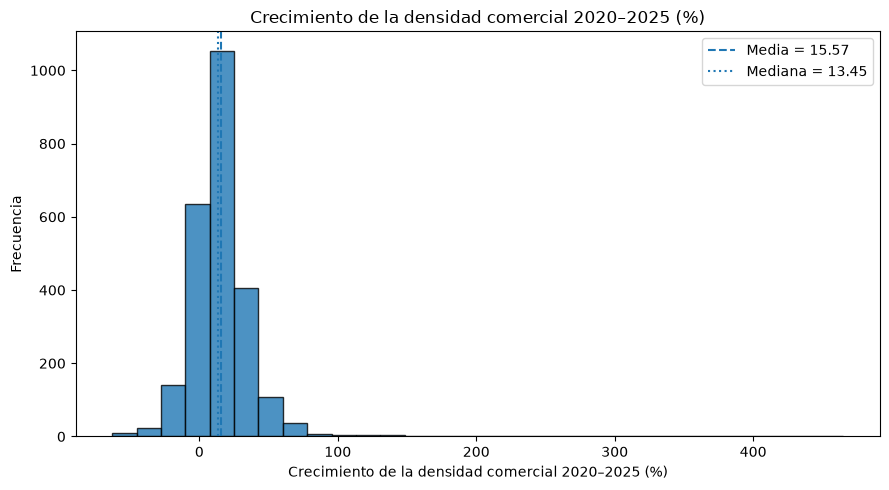

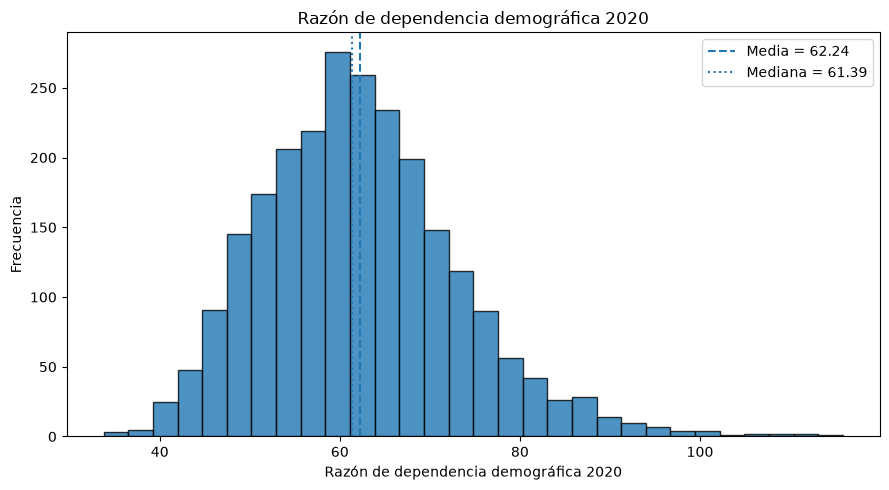

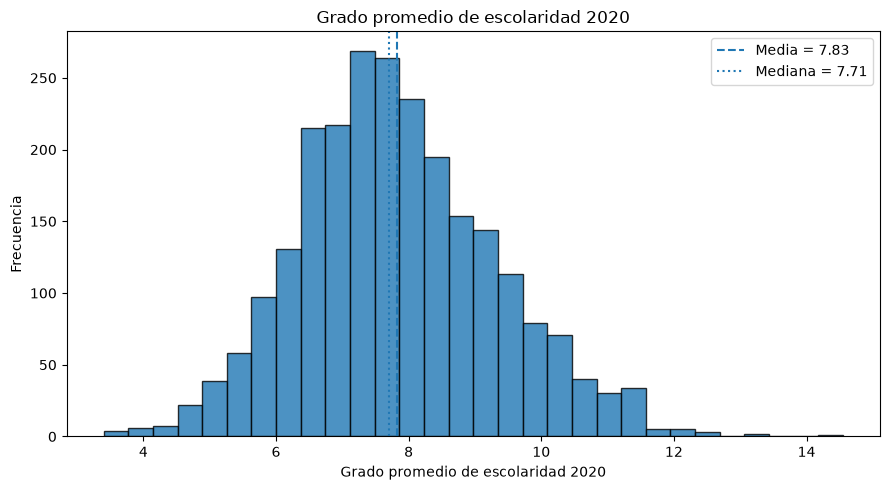

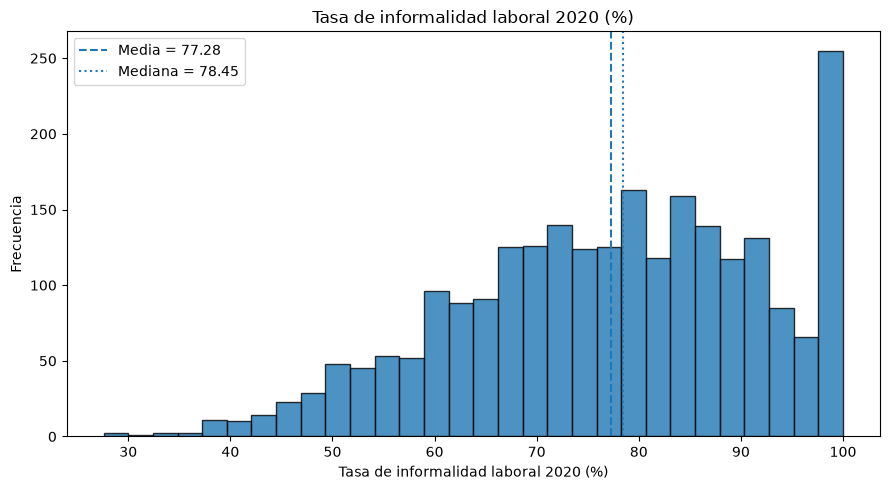

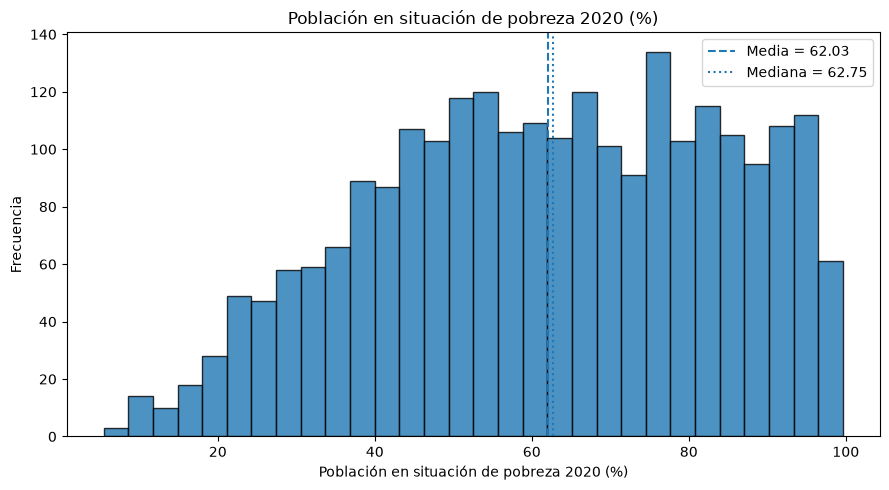

In [42]:
for variable, titulo in variables_graficas.items():

    plt.figure(figsize=(9, 5))

    plt.hist(
        base_maestra[variable],
        bins=30,
        edgecolor="black",
        alpha=0.8
    )

    plt.axvline(
        base_maestra[variable].mean(),
        linestyle="--",
        linewidth=1.5,
        label=f"Media = {base_maestra[variable].mean():.2f}"
    )

    plt.axvline(
        base_maestra[variable].median(),
        linestyle=":",
        linewidth=1.5,
        label=f"Mediana = {base_maestra[variable].median():.2f}"
    )

    plt.title(titulo)
    plt.xlabel(titulo)
    plt.ylabel("Frecuencia")

    plt.legend()

    plt.tight_layout()

    nombre_archivo = (
        f"histograma_{variable.lower()}.png"
    )

    plt.savefig(
        GRAFICAS_DIR / nombre_archivo,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### 3.8 Diagramas de caja de las variables del modelo

Los diagramas de caja permiten visualizar la posición de la mediana, los cuartiles, la dispersión central y las observaciones identificadas como potencialmente atípicas.

Los puntos localizados fuera de los bigotes no se eliminan automáticamente. Se consideran observaciones que requieren análisis adicional antes de decidir su tratamiento econométrico.

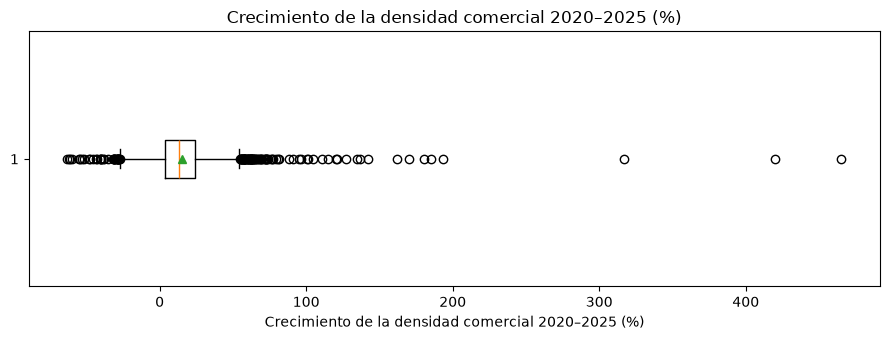

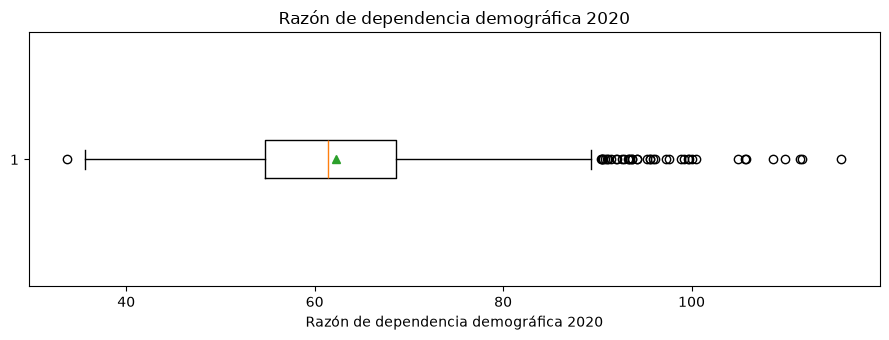

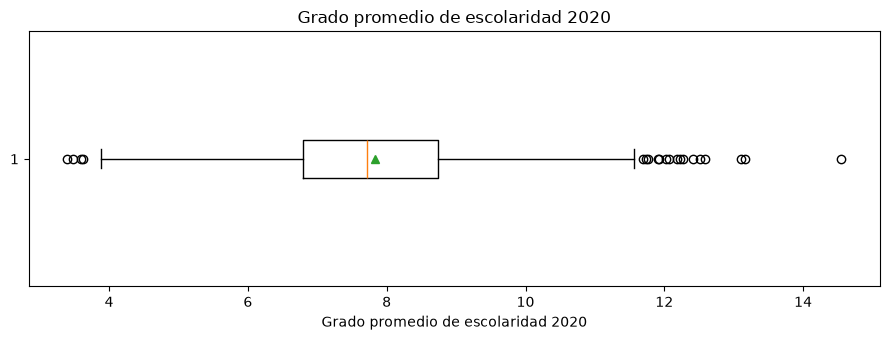

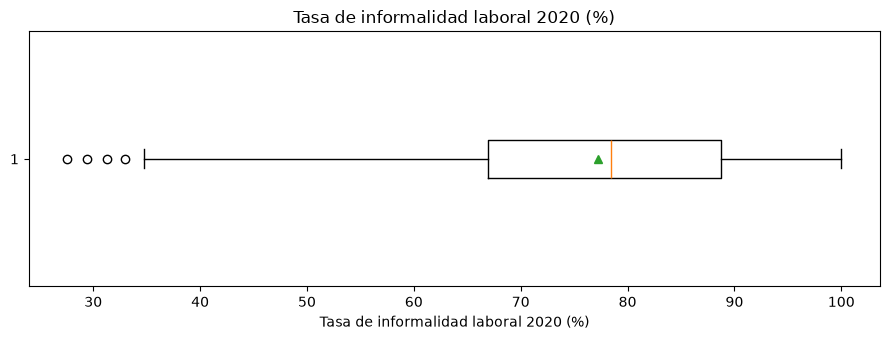

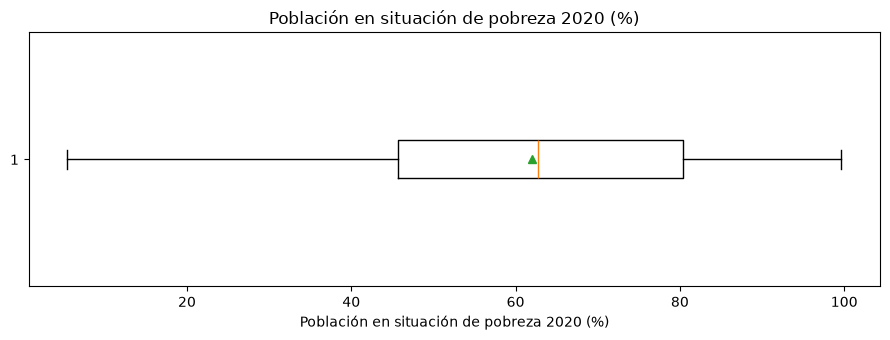

In [48]:
for variable, titulo in variables_graficas.items():

    plt.figure(figsize=(9, 3.5))

    plt.boxplot(
        base_maestra[variable],
       orientation="horizontal",
    showmeans=True
)

    plt.title(titulo)
    plt.xlabel(titulo)

    plt.tight_layout()

    nombre_archivo = (
        f"boxplot_{variable.lower()}.png"
    )

    plt.savefig(
        GRAFICAS_DIR / nombre_archivo,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

##3.9 Comparación gráfica de Y porcentual vs. Y logarítmica

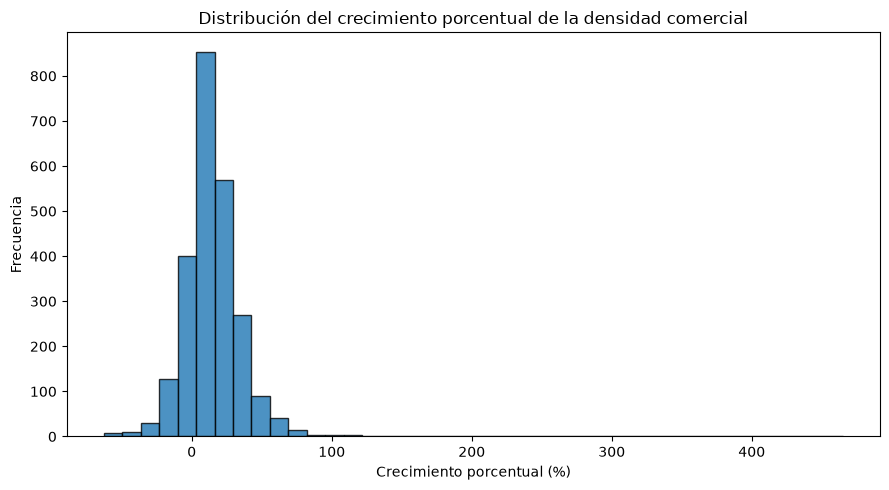

In [44]:
### Primero el histograma de la versión porcentual

plt.figure(figsize=(9, 5))

plt.hist(
    base_maestra["CREC_DENSIDAD_RETAIL_2020_2025"],
    bins=40,
    edgecolor="black",
    alpha=0.8
)

plt.title(
    "Distribución del crecimiento porcentual "
    "de la densidad comercial"
)

plt.xlabel("Crecimiento porcentual (%)")
plt.ylabel("Frecuencia")

plt.tight_layout()

plt.savefig(
    GRAFICAS_DIR / "comparacion_y_porcentual.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

###3.10 Control de archivos generados



In [45]:
graficas_generadas = sorted(
    GRAFICAS_DIR.glob("*.png")
)

print(
    "Número de gráficas guardadas:",
    len(graficas_generadas)
)

for archivo in graficas_generadas:
    print(archivo.name)

Número de gráficas guardadas: 11
boxplot_crec_densidad_retail_2020_2025.png
boxplot_graproes_2020.png
boxplot_pobreza_2020.png
boxplot_raz_dep_2020.png
boxplot_tasa_informalidad_2020.png
comparacion_y_porcentual.png
histograma_crec_densidad_retail_2020_2025.png
histograma_graproes_2020.png
histograma_pobreza_2020.png
histograma_raz_dep_2020.png
histograma_tasa_informalidad_2020.png


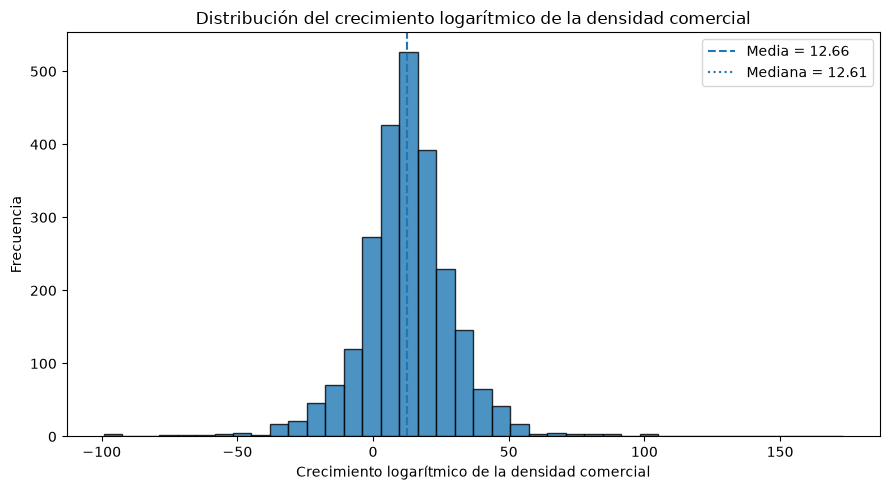

In [49]:
#### comparacion_y_logaritmica.png

plt.figure(figsize=(9, 5))

plt.hist(
    base_maestra[
        "CREC_LOG_DENSIDAD_RETAIL_2020_2025"
    ],
    bins=40,
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    base_maestra[
        "CREC_LOG_DENSIDAD_RETAIL_2020_2025"
    ].mean(),
    linestyle="--",
    linewidth=1.5,
    label=(
        "Media = "
        f"{base_maestra['CREC_LOG_DENSIDAD_RETAIL_2020_2025'].mean():.2f}"
    )
)

plt.axvline(
    base_maestra[
        "CREC_LOG_DENSIDAD_RETAIL_2020_2025"
    ].median(),
    linestyle=":",
    linewidth=1.5,
    label=(
        "Mediana = "
        f"{base_maestra['CREC_LOG_DENSIDAD_RETAIL_2020_2025'].median():.2f}"
    )
)

plt.title(
    "Distribución del crecimiento logarítmico "
    "de la densidad comercial"
)

plt.xlabel(
    "Crecimiento logarítmico de la densidad comercial"
)

plt.ylabel("Frecuencia")

plt.legend()
plt.tight_layout()

plt.savefig(
    GRAFICAS_DIR / "comparacion_y_logaritmica.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [50]:
graficas_generadas = sorted(
    GRAFICAS_DIR.glob("*.png")
)

print(
    "Número de gráficas guardadas:",
    len(graficas_generadas)
)

for archivo in graficas_generadas:
    print(archivo.name)

Número de gráficas guardadas: 12
boxplot_crec_densidad_retail_2020_2025.png
boxplot_graproes_2020.png
boxplot_pobreza_2020.png
boxplot_raz_dep_2020.png
boxplot_tasa_informalidad_2020.png
comparacion_y_logaritmica.png
comparacion_y_porcentual.png
histograma_crec_densidad_retail_2020_2025.png
histograma_graproes_2020.png
histograma_pobreza_2020.png
histograma_raz_dep_2020.png
histograma_tasa_informalidad_2020.png


### 3.9 Conclusión del análisis gráfico descriptivo

Los histogramas y diagramas de caja confirman comportamientos diferenciados entre las variables del modelo.

La variable dependiente presenta una distribución fuertemente asimétrica a la derecha y valores extremos, principalmente asociados con crecimientos comerciales elevados. Estos valores no se eliminarán automáticamente, ya que los controles previos no identificaron errores de información y se consideran observaciones válidas sujetas a diagnóstico de influencia.

La razón de dependencia presenta una asimetría positiva moderada y algunos valores elevados. El grado promedio de escolaridad muestra una distribución relativamente equilibrada, con pocos valores extremos. La tasa de informalidad se concentra en niveles altos y presenta algunos valores bajos identificados como atípicos, mientras que el límite de 100% corresponde a una restricción natural de la variable. La pobreza presenta una elevada heterogeneidad municipal, pero no registra observaciones atípicas según el criterio IQR.

En consecuencia, no se eliminan observaciones ni se modifican las variables explicativas en esta etapa.

### 3.10 Análisis de correlación de Pearson

Se analiza la asociación lineal entre la variable dependiente y las variables explicativas mediante el coeficiente de correlación de Pearson.

El coeficiente puede tomar valores entre -1 y 1:

- valores positivos indican relación lineal positiva;
- valores negativos indican relación lineal negativa;
- valores cercanos a cero indican ausencia o debilidad de relación lineal.

La correlación no implica causalidad y se utilizará como análisis exploratorio previo a la estimación econométrica.

También se revisarán las correlaciones entre las variables explicativas para identificar posibles asociaciones elevadas que posteriormente puedan generar problemas de multicolinealidad en la regresión múltiple.

In [51]:
variables_correlacion = [
    "CREC_DENSIDAD_RETAIL_2020_2025",
    "RAZ_DEP_2020",
    "GRAPROES_2020",
    "TASA_INFORMALIDAD_2020",
    "POBREZA_2020"
]

matriz_correlacion = (
    base_maestra[
        variables_correlacion
    ]
    .corr(method="pearson")
)

display(
    matriz_correlacion.round(4)
)

,CREC_DENSIDAD_RETAIL_2020_2025,RAZ_DEP_2020,GRAPROES_2020,TASA_INFORMALIDAD_2020,POBREZA_2020
CREC_DENSIDAD_RETAIL_2020_2025,1.0000,-0.0043,-0.0709,0.0734,0.1142
RAZ_DEP_2020,-0.0043,1.0000,-0.7393,0.6859,0.5374
GRAPROES_2020,-0.0709,-0.7393,1.0000,-0.7484,-0.6985
TASA_INFORMALIDAD_2020,0.0734,0.6859,-0.7484,1.0000,0.7148
POBREZA_2020,0.1142,0.5374,-0.6985,0.7148,1.0000


In [52]:
nombres_cortos = {
    "CREC_DENSIDAD_RETAIL_2020_2025": "Y_Crec_Densidad",
    "RAZ_DEP_2020": "X1_Dependencia",
    "GRAPROES_2020": "X2_Escolaridad",
    "TASA_INFORMALIDAD_2020": "X3_Informalidad",
    "POBREZA_2020": "X4_Pobreza"
}

matriz_correlacion_presentacion = (
    base_maestra[
        variables_correlacion
    ]
    .rename(columns=nombres_cortos)
    .corr(method="pearson")
)

display(
    matriz_correlacion_presentacion.round(4)
)

,Y_Crec_Densidad,X1_Dependencia,X2_Escolaridad,X3_Informalidad,X4_Pobreza
Y_Crec_Densidad,1.0000,-0.0043,-0.0709,0.0734,0.1142
X1_Dependencia,-0.0043,1.0000,-0.7393,0.6859,0.5374
X2_Escolaridad,-0.0709,-0.7393,1.0000,-0.7484,-0.6985
X3_Informalidad,0.0734,0.6859,-0.7484,1.0000,0.7148
X4_Pobreza,0.1142,0.5374,-0.6985,0.7148,1.0000


In [53]:
correlaciones_y = (
    matriz_correlacion_presentacion[
        "Y_Crec_Densidad"
    ]
    .drop("Y_Crec_Densidad")
    .sort_values(
        key=abs,
        ascending=False
    )
)

display(
    correlaciones_y.to_frame(
        name="Correlacion_con_Y"
    ).round(4)
)

,Correlacion_con_Y
X4_Pobreza,0.1142
X3_Informalidad,0.0734
X2_Escolaridad,-0.0709
X1_Dependencia,-0.0043


### 3.10 Matriz de correlaciones de Pearson

Se analiza la asociación lineal entre la variable dependiente y las cuatro variables explicativas mediante el coeficiente de correlación de Pearson.

La escala de colores se interpreta de la siguiente manera:

- tonos rojos: correlación positiva;
- tonos azules: correlación negativa;
- tonos claros: correlación cercana a cero.

La intensidad del color representa la magnitud de la relación lineal.

El coeficiente de Pearson toma valores entre -1 y 1. Valores cercanos a ±1 indican una asociación lineal fuerte, mientras que valores cercanos a cero indican una relación lineal débil.

La correlación no implica causalidad y constituye únicamente una herramienta exploratoria previa a la estimación de los modelos de regresión.

,Y: Crecimiento densidad,X1: Dependencia,X2: Escolaridad,X3: Informalidad,X4: Pobreza
Y: Crecimiento densidad,1.0000,-0.0043,-0.0709,0.0734,0.1142
X1: Dependencia,-0.0043,1.0000,-0.7393,0.6859,0.5374
X2: Escolaridad,-0.0709,-0.7393,1.0000,-0.7484,-0.6985
X3: Informalidad,0.0734,0.6859,-0.7484,1.0000,0.7148
X4: Pobreza,0.1142,0.5374,-0.6985,0.7148,1.0000


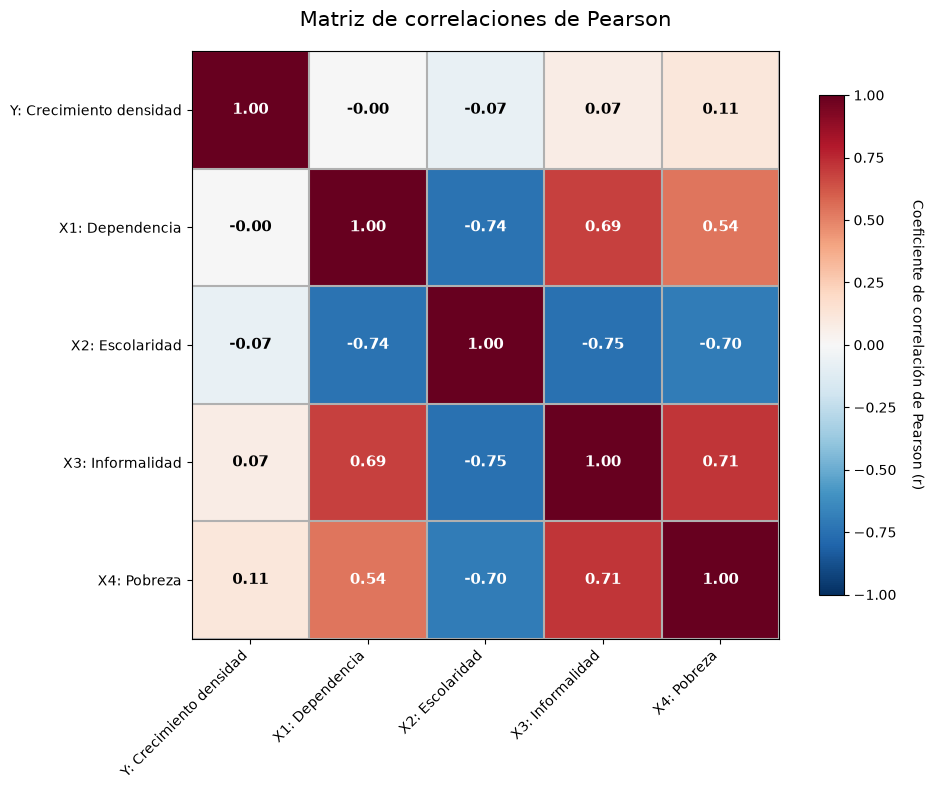

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# VARIABLES PARA LA MATRIZ DE CORRELACIÓN
# ============================================================

variables_correlacion = {
    "CREC_DENSIDAD_RETAIL_2020_2025": "Y: Crecimiento densidad",
    "RAZ_DEP_2020": "X1: Dependencia",
    "GRAPROES_2020": "X2: Escolaridad",
    "TASA_INFORMALIDAD_2020": "X3: Informalidad",
    "POBREZA_2020": "X4: Pobreza"
}

# Seleccionar y renombrar variables
datos_correlacion = (
    base_maestra[
        list(variables_correlacion.keys())
    ]
    .rename(columns=variables_correlacion)
)

# ============================================================
# MATRIZ DE CORRELACIÓN DE PEARSON
# ============================================================

matriz_correlacion = (
    datos_correlacion
    .corr(method="pearson")
)

display(matriz_correlacion.round(4))


# ============================================================
# GRÁFICO DE CORRELACIÓN
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

# Escala:
# -1 = azul intenso
#  0 = blanco
# +1 = rojo intenso
imagen = ax.imshow(
    matriz_correlacion,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1
)

# Barra lateral de escala
barra = fig.colorbar(
    imagen,
    ax=ax,
    shrink=0.85
)

barra.set_label(
    "Coeficiente de correlación de Pearson (r)",
    rotation=270,
    labelpad=20
)

# Etiquetas de los ejes
ax.set_xticks(
    np.arange(len(matriz_correlacion.columns))
)

ax.set_yticks(
    np.arange(len(matriz_correlacion.index))
)

ax.set_xticklabels(
    matriz_correlacion.columns,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    matriz_correlacion.index
)

# ============================================================
# MOSTRAR EL VALOR DE r EN CADA CELDA
# ============================================================

for i in range(len(matriz_correlacion.index)):
    for j in range(len(matriz_correlacion.columns)):

        valor = matriz_correlacion.iloc[i, j]

        # Texto blanco cuando el fondo es intenso
        color_texto = (
            "white"
            if abs(valor) >= 0.50
            else "black"
        )

        ax.text(
            j,
            i,
            f"{valor:.2f}",
            ha="center",
            va="center",
            color=color_texto,
            fontsize=11,
            fontweight="bold"
        )

# Título
ax.set_title(
    "Matriz de correlaciones de Pearson",
    fontsize=15,
    pad=18
)

# Cuadrícula para separar visualmente las celdas
ax.set_xticks(
    np.arange(-0.5, len(matriz_correlacion.columns), 1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5, len(matriz_correlacion.index), 1),
    minor=True
)

ax.grid(
    which="minor",
    linewidth=1.5
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)

plt.tight_layout()

# ============================================================
# GUARDAR GRÁFICA
# ============================================================

plt.savefig(
    GRAFICAS_DIR / "matriz_correlacion_pearson.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 3.11 Correlaciones de Pearson con la variable dependiente

Además de la magnitud del coeficiente de correlación, se evalúa su significancia estadística mediante la prueba asociada al coeficiente de Pearson.

La significancia estadística no debe confundirse con la magnitud económica de la relación. Debido al tamaño de la muestra, asociaciones lineales pequeñas pueden resultar estadísticamente significativas.

In [56]:
tabla_pearson["Significativa_5pct"] = (
    tabla_pearson["p_value"] < 0.05
)

tabla_pearson["p_value_formato"] = (
    tabla_pearson["p_value"]
    .apply(
        lambda p:
        "< 0.001"
        if p < 0.001
        else f"{p:.4f}"
    )
)

display(
    tabla_pearson[
        [
            "Variable",
            "r_Pearson",
            "p_value_formato",
            "Significativa_5pct"
        ]
    ].round({
        "r_Pearson": 4
    })
)

,Variable,r_Pearson,p_value_formato,Significativa_5pct
0,X4_Pobreza,0.1142,< 0.001,True
1,X3_Informalidad,0.0734,< 0.001,True
2,X2_Escolaridad,-0.0709,< 0.001,True
3,X1_Dependencia,-0.0043,0.8300,False


##diagramas de dispersión con línea de tendencia

In [57]:
# =========================================================
# 1. Librerías
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

Las gráficas se guardarán en:
c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\notebooks\graficas_modelo


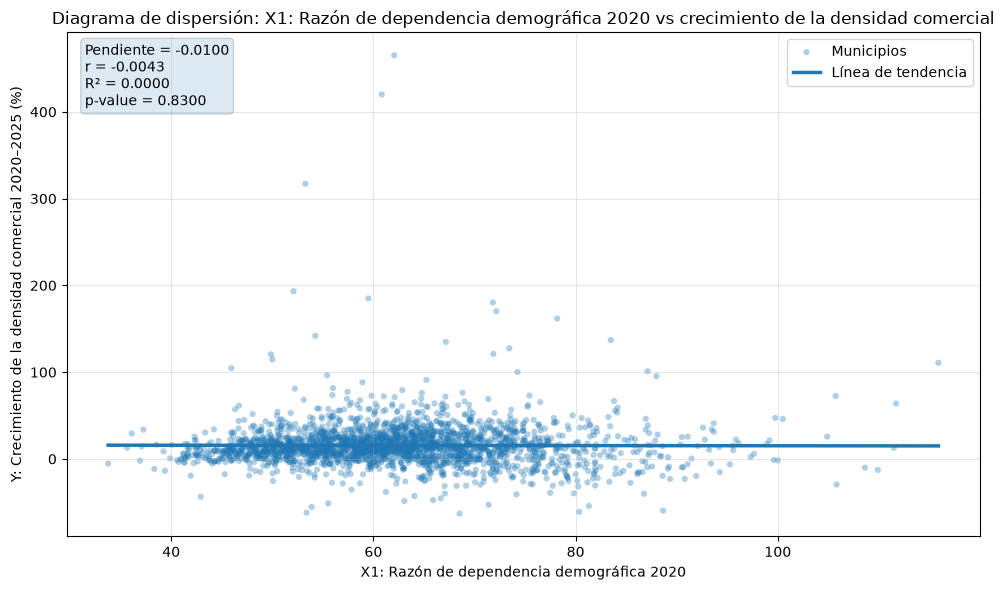

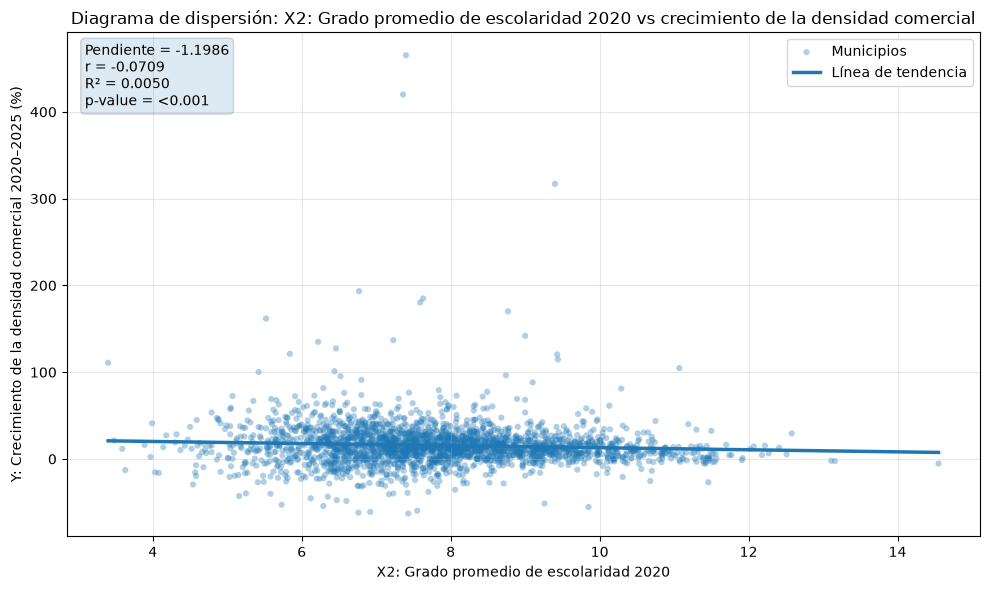

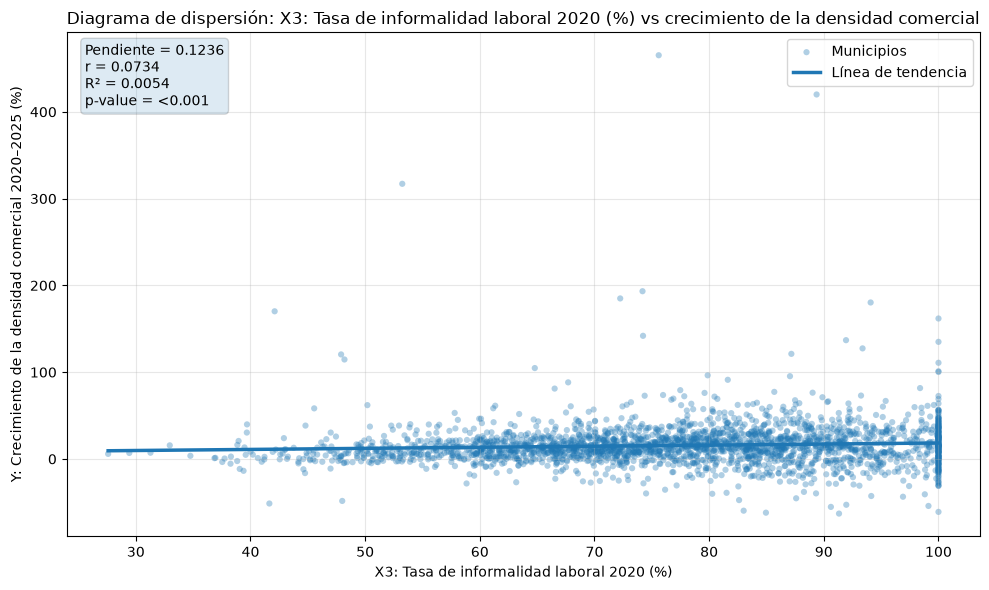

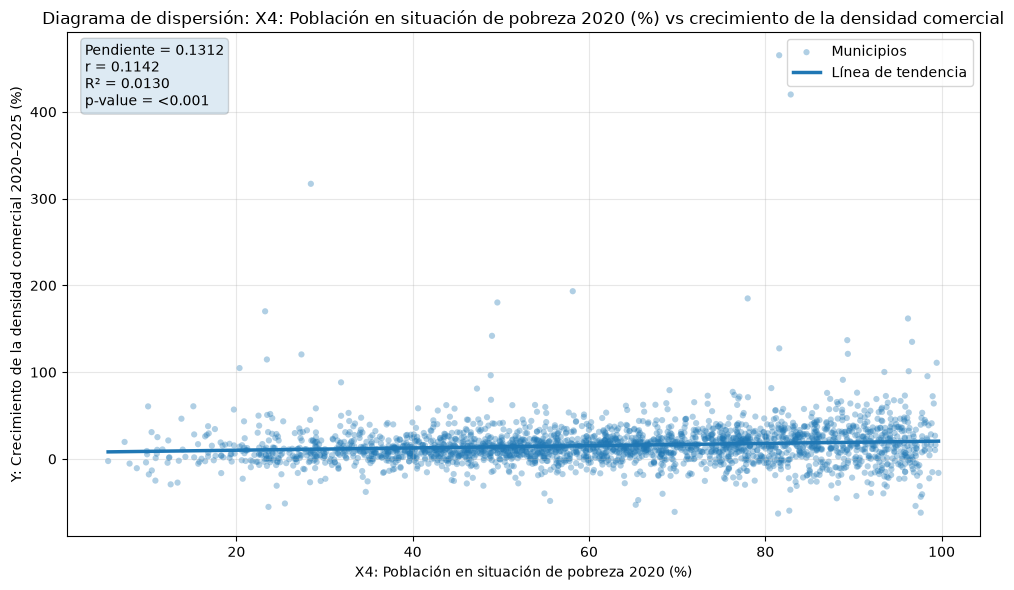

,Variable_X,Pendiente,r,R2,p_value,N,archivo
0,RAZ_DEP_2020,-0.009975,-0.004350,0.000019,0.829969,2440,c:\Users\nashe\Desktop\Econometría\PROYECTO\at...
1,GRAPROES_2020,-1.198569,-0.070946,0.005033,0.000453,2440,c:\Users\nashe\Desktop\Econometría\PROYECTO\at...
2,TASA_INFORMALIDAD_2020,0.123592,0.073356,0.005381,0.000287,2440,c:\Users\nashe\Desktop\Econometría\PROYECTO\at...
3,POBREZA_2020,0.131166,0.114231,0.013049,0.000000,2440,c:\Users\nashe\Desktop\Econometría\PROYECTO\at...


In [58]:


# =========================================================
# 2. Variables del modelo
# =========================================================
Y = "CREC_DENSIDAD_RETAIL_2020_2025"

variables_dispersion = [
    ("RAZ_DEP_2020", "X1: Razón de dependencia demográfica 2020", "dispersion_x1_raz_dep_2020.png"),
    ("GRAPROES_2020", "X2: Grado promedio de escolaridad 2020", "dispersion_x2_graproes_2020.png"),
    ("TASA_INFORMALIDAD_2020", "X3: Tasa de informalidad laboral 2020 (%)", "dispersion_x3_informalidad_2020.png"),
    ("POBREZA_2020", "X4: Población en situación de pobreza 2020 (%)", "dispersion_x4_pobreza_2020.png")
]

# =========================================================
# 3. Carpeta de guardado (opcional)
# =========================================================
# Si ya tienes GRAFICOS_DIR definido, usa ese.
# Si no existe, se crea una carpeta llamada "graficas_modelo" en el proyecto.
from pathlib import Path

if "GRAFICOS_DIR" in globals():
    carpeta_graficas = GRAFICOS_DIR
else:
    carpeta_graficas = Path.cwd() / "graficas_modelo"
    carpeta_graficas.mkdir(parents=True, exist_ok=True)

print("Las gráficas se guardarán en:")
print(carpeta_graficas)

# =========================================================
# 4. Función para graficar dispersión con línea de tendencia
# =========================================================
def grafica_dispersion_con_tendencia(df, x_col, y_col, x_label, archivo_salida):
    datos = df[[x_col, y_col]].dropna().copy()

    x = datos[x_col]
    y = datos[y_col]

    # Regresión lineal simple para la línea de tendencia
    resultado = linregress(x, y)

    pendiente = resultado.slope
    intercepto = resultado.intercept
    r = resultado.rvalue
    p = resultado.pvalue
    r2 = r**2

    # Generar línea
    x_linea = np.linspace(x.min(), x.max(), 200)
    y_linea = intercepto + pendiente * x_linea

    # Figura
    plt.figure(figsize=(10, 6))
    plt.scatter(
        x, y,
        alpha=0.35,
        s=20,
        edgecolors="none",
        label="Municipios"
    )
    plt.plot(
        x_linea, y_linea,
        linewidth=2.5,
        label="Línea de tendencia"
    )

    plt.title(f"Diagrama de dispersión: {x_label} vs crecimiento de la densidad comercial")
    plt.xlabel(x_label)
    plt.ylabel("Y: Crecimiento de la densidad comercial 2020–2025 (%)")
    plt.grid(True, alpha=0.3)

    # Texto resumen dentro del gráfico
    texto_resumen = (
        f"Pendiente = {pendiente:.4f}\n"
        f"r = {r:.4f}\n"
        f"R² = {r2:.4f}\n"
        f"p-value = {'<0.001' if p < 0.001 else f'{p:.4f}'}"
    )

    plt.text(
        0.02, 0.98,
        texto_resumen,
        transform=plt.gca().transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", alpha=0.15)
    )

    plt.legend()
    plt.tight_layout()

    # Guardar
    ruta_salida = carpeta_graficas / archivo_salida
    plt.savefig(ruta_salida, dpi=300, bbox_inches="tight")
    plt.show()

    return {
        "Variable_X": x_col,
        "Pendiente": pendiente,
        "Intercepto": intercepto,
        "r": r,
        "R2": r2,
        "p_value": p,
        "N": len(datos),
        "archivo": str(ruta_salida)
    }

# =========================================================
# 5. Generar las 4 gráficas
# =========================================================
resultados_dispersion = []

for x_col, etiqueta_x, archivo in variables_dispersion:
    resultado = grafica_dispersion_con_tendencia(
        df=base_maestra,
        x_col=x_col,
        y_col=Y,
        x_label=etiqueta_x,
        archivo_salida=archivo
    )
    resultados_dispersion.append(resultado)

# =========================================================
# 6. Resumen de resultados
# =========================================================
tabla_resultados_dispersion = pd.DataFrame(resultados_dispersion)

display(
    tabla_resultados_dispersion[
        ["Variable_X", "Pendiente", "r", "R2", "p_value", "N", "archivo"]
    ].round(6)
)

##3.12 Comparación Y porcentual vs. Y logarítmica

### 3.12 Comparación de relaciones lineales: Y porcentual vs. Y logarítmica

Se compara la asociación de las cuatro variables explicativas con dos especificaciones de la variable dependiente:

- crecimiento porcentual de la densidad comercial;
- crecimiento logarítmico de la densidad comercial.

El objetivo es determinar si la transformación logarítmica modifica de manera importante:

- la dirección de las relaciones;
- la magnitud de la correlación de Pearson;
- la capacidad explicativa bivariada;
- la significancia estadística.

Las pendientes de ambas especificaciones no deben compararse directamente en magnitud, debido a que las variables dependientes se encuentran expresadas bajo transformaciones diferentes.

In [61]:
# ============================================================
# COMPARACIÓN Y PORCENTUAL VS Y LOGARÍTMICA
# ============================================================

from scipy.stats import pearsonr, linregress
import pandas as pd
import numpy as np


# Variables dependientes
Y_PCT = "CREC_DENSIDAD_RETAIL_2020_2025"
Y_LOG = "CREC_LOG_DENSIDAD_RETAIL_2020_2025"


# Variables explicativas
variables_x_comparacion = {
    "X1_Dependencia": "RAZ_DEP_2020",
    "X2_Escolaridad": "GRAPROES_2020",
    "X3_Informalidad": "TASA_INFORMALIDAD_2020",
    "X4_Pobreza": "POBREZA_2020"
}


# Verificar que todas las variables existan
variables_necesarias = (
    [Y_PCT, Y_LOG]
    + list(variables_x_comparacion.values())
)

variables_faltantes = [
    variable
    for variable in variables_necesarias
    if variable not in base_maestra.columns
]

print("Variables faltantes:", variables_faltantes)

assert len(variables_faltantes) == 0, \
    "Faltan variables necesarias para construir la tabla."


# ============================================================
# CALCULAR RESULTADOS
# ============================================================

resultados_comparacion = []

for nombre_x, variable_x in variables_x_comparacion.items():

    datos = base_maestra[
        [
            variable_x,
            Y_PCT,
            Y_LOG
        ]
    ].dropna()

    x = datos[variable_x]

    # --------------------------------------------------------
    # Y PORCENTUAL
    # --------------------------------------------------------

    regresion_pct = linregress(
        x,
        datos[Y_PCT]
    )

    r_pct = regresion_pct.rvalue
    p_pct = regresion_pct.pvalue

    # --------------------------------------------------------
    # Y LOGARÍTMICA
    # --------------------------------------------------------

    regresion_log = linregress(
        x,
        datos[Y_LOG]
    )

    r_log = regresion_log.rvalue
    p_log = regresion_log.pvalue

    # --------------------------------------------------------
    # GUARDAR RESULTADOS
    # --------------------------------------------------------

    resultados_comparacion.append({

        "Variable": nombre_x,

        # Y porcentual
        "Pendiente_Y_pct": regresion_pct.slope,
        "r_Y_pct": r_pct,
        "R2_Y_pct": r_pct ** 2,
        "p_Y_pct": p_pct,

        # Y logarítmica
        "Pendiente_Y_log": regresion_log.slope,
        "r_Y_log": r_log,
        "R2_Y_log": r_log ** 2,
        "p_Y_log": p_log,

        # Comparaciones
        "Cambio_abs_r": abs(r_log) - abs(r_pct),
        "Cambio_R2": (r_log ** 2) - (r_pct ** 2),

        "N": len(datos)
    })


tabla_comparativa_y = pd.DataFrame(
    resultados_comparacion
)

display(
    tabla_comparativa_y.round(6)
)

Variables faltantes: []


,Variable,Pendiente_Y_pct,r_Y_pct,R2_Y_pct,p_Y_pct,Pendiente_Y_log,r_Y_log,R2_Y_log,p_Y_log,Cambio_abs_r,Cambio_R2,N
0,X1_Dependencia,-0.009975,-0.004350,0.000019,0.829969,-0.059262,-0.034872,0.001216,0.085035,0.030523,0.001197,2440
1,X2_Escolaridad,-1.198569,-0.070946,0.005033,0.000453,-0.688366,-0.054985,0.003023,0.006593,-0.015961,-0.002010,2440
2,X3_Informalidad,0.123592,0.073356,0.005381,0.000287,0.076827,0.061534,0.003786,0.002359,-0.011822,-0.001595,2440
3,X4_Pobreza,0.131166,0.114231,0.013049,0.000000,0.091867,0.107965,0.011656,0.000000,-0.006266,-0.001392,2440


In [62]:
tabla_comparativa_resumen = (
    tabla_comparativa_y[
        [
            "Variable",
            "r_Y_pct",
            "R2_Y_pct",
            "p_Y_pct",
            "r_Y_log",
            "R2_Y_log",
            "p_Y_log",
            "Cambio_abs_r",
            "Cambio_R2"
        ]
    ]
    .copy()
)


# Formatear p-values
def formatear_p_value(p):

    if p < 0.001:
        return "< 0.001"
    else:
        return f"{p:.4f}"


tabla_comparativa_resumen["p_Y_pct"] = (
    tabla_comparativa_resumen["p_Y_pct"]
    .apply(formatear_p_value)
)

tabla_comparativa_resumen["p_Y_log"] = (
    tabla_comparativa_resumen["p_Y_log"]
    .apply(formatear_p_value)
)


display(
    tabla_comparativa_resumen.round({
        "r_Y_pct": 4,
        "R2_Y_pct": 4,
        "r_Y_log": 4,
        "R2_Y_log": 4,
        "Cambio_abs_r": 4,
        "Cambio_R2": 4
    })
)

,Variable,r_Y_pct,R2_Y_pct,p_Y_pct,r_Y_log,R2_Y_log,p_Y_log,Cambio_abs_r,Cambio_R2
0,X1_Dependencia,-0.0043,0.0000,0.8300,-0.0349,0.0012,0.0850,0.0305,0.0012
1,X2_Escolaridad,-0.0709,0.0050,< 0.001,-0.0550,0.0030,0.0066,-0.0160,-0.0020
2,X3_Informalidad,0.0734,0.0054,< 0.001,0.0615,0.0038,0.0024,-0.0118,-0.0016
3,X4_Pobreza,0.1142,0.0130,< 0.001,0.1080,0.0117,< 0.001,-0.0063,-0.0014


### 3.13 Conclusión de la comparación entre Y porcentual y Y logarítmica

La transformación logarítmica reduce de manera considerable la asimetría y la curtosis de la variable dependiente. Sin embargo, las relaciones lineales con las cuatro variables explicativas permanecen débiles.

Los signos de las correlaciones son estables entre ambas especificaciones:

- la razón de dependencia mantiene una relación negativa prácticamente nula;
- la escolaridad mantiene una relación negativa débil;
- la informalidad mantiene una relación positiva débil;
- la pobreza mantiene la mayor correlación positiva, aunque su magnitud continúa siendo pequeña.

En tres de las cuatro variables explicativas, el valor absoluto de la correlación y el R² bivariado disminuyen ligeramente al utilizar el crecimiento logarítmico. La razón de dependencia muestra una pequeña mejora, pero su asociación continúa siendo muy débil y no resulta estadísticamente significativa al 5%.

Por tanto, la débil asociación lineal observada entre las variables socioeconómicas y el crecimiento de la densidad comercial no parece ser consecuencia exclusiva de los valores extremos de la variable dependiente porcentual.

Se conservará el crecimiento porcentual como especificación principal debido a su interpretación económica directa, mientras que el crecimiento logarítmico será utilizado posteriormente como especificación alternativa para evaluar robustez y forma funcional.

Variable dependiente logarítmica utilizada: CREC_LOG_DENSIDAD_RETAIL_2020_2025
Las gráficas se guardarán en:
c:\Users\nashe\Desktop\Econometría\PROYECTO\atractividad_comercial_Mexico\outputs\graficas


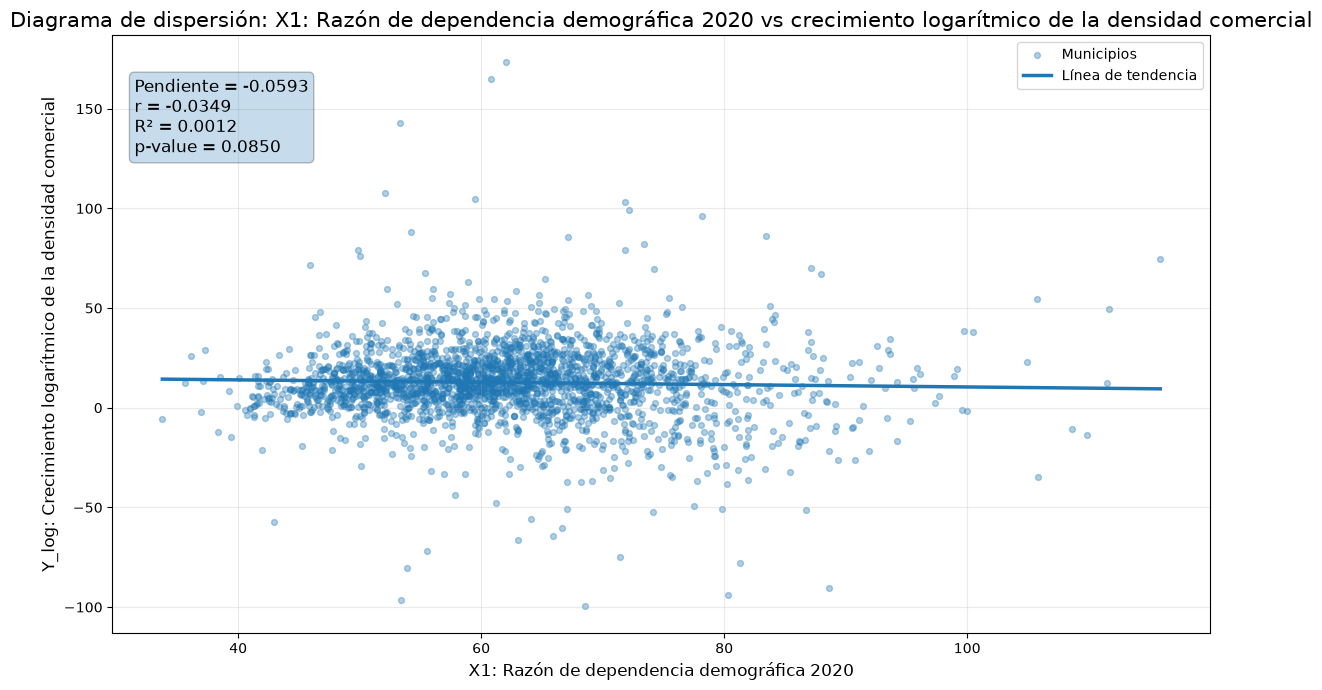

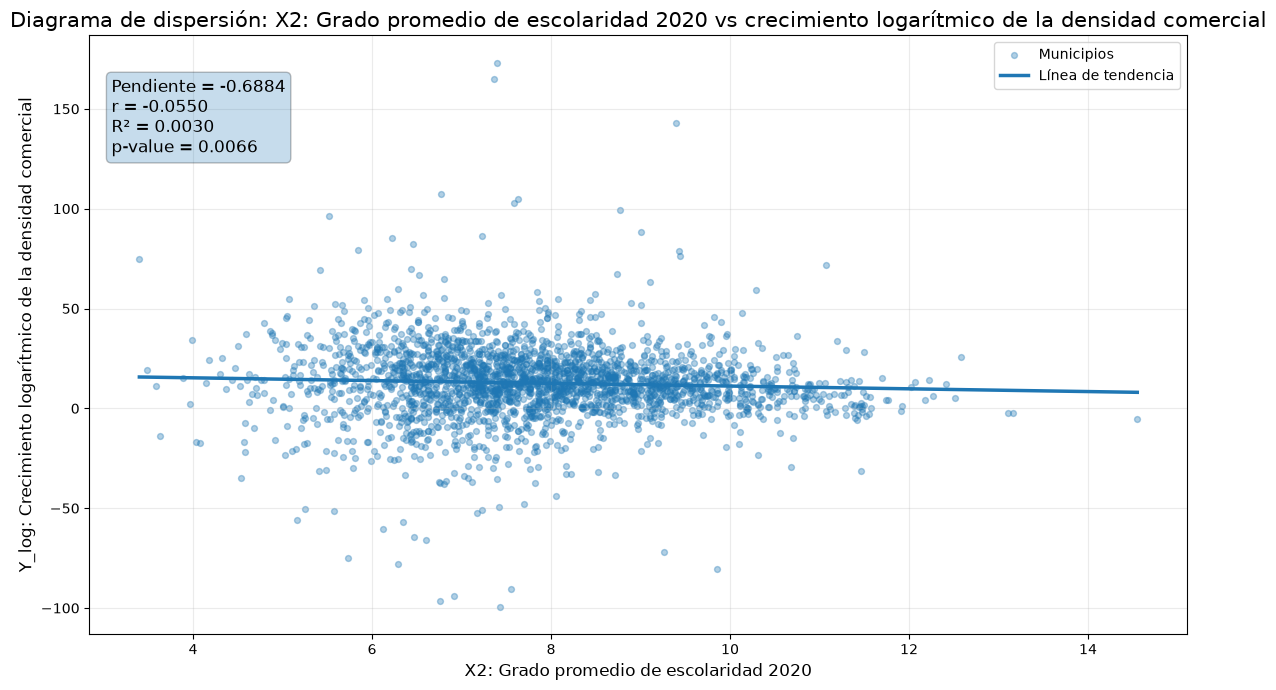

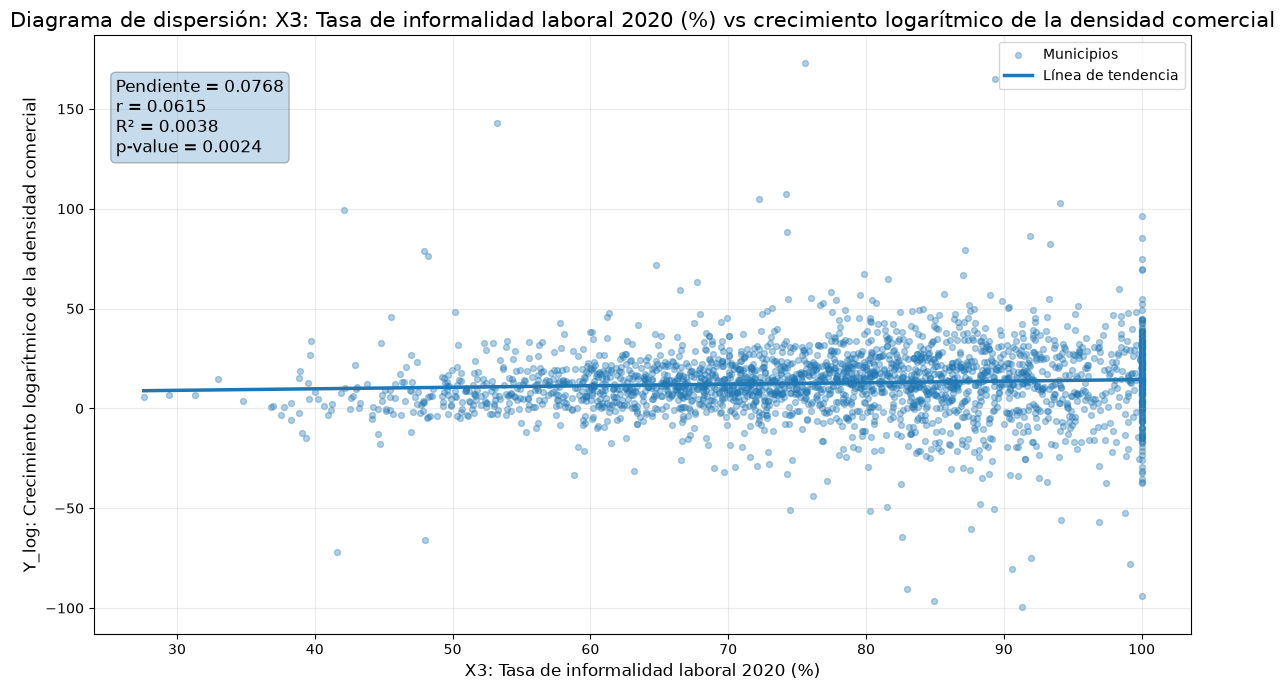

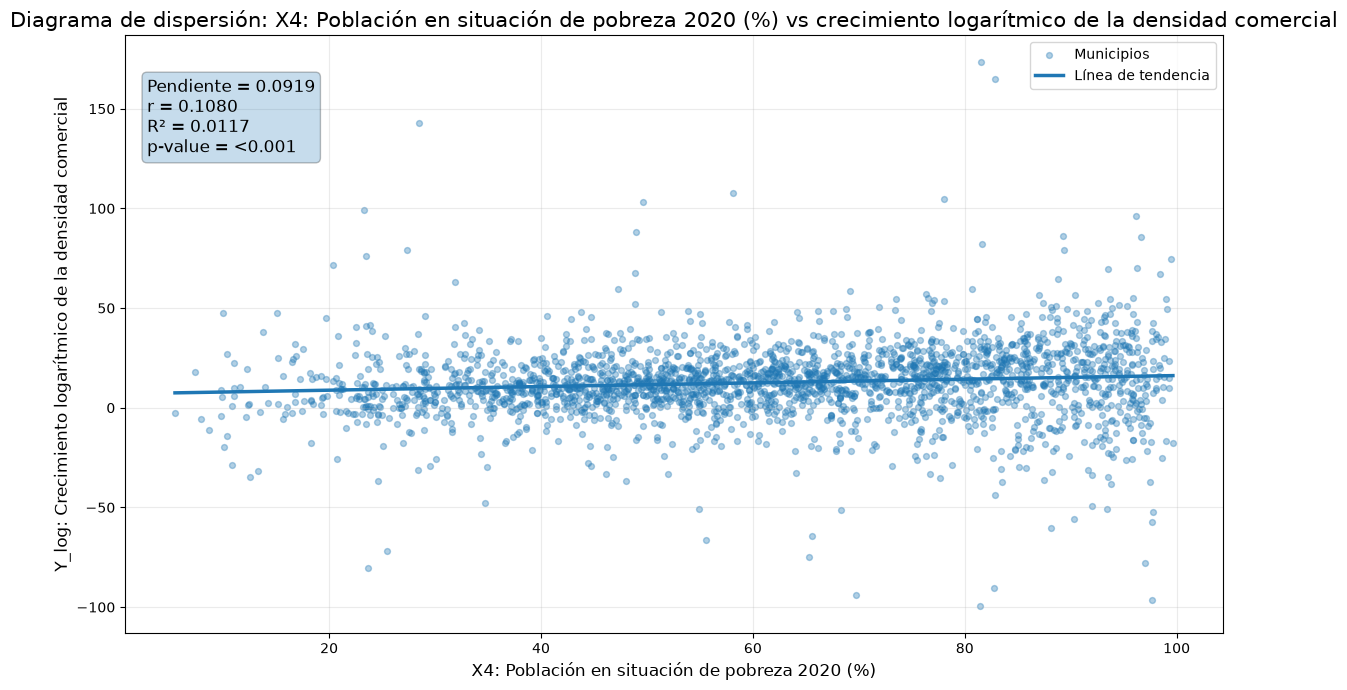


Número de gráficas guardadas: 4
scatter_log_raz_dep_2020.png
scatter_log_graproes_2020.png
scatter_log_tasa_informalidad_2020.png
scatter_log_pobreza_2020.png


In [63]:
# =========================================================
# SCATTER PLOTS: X vs Y logarítmica
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ---------------------------------------------------------
# 1. Definir variable dependiente logarítmica
# ---------------------------------------------------------
# Aquí se asume que YA tienes definida la variable Y_LOG
# como el nombre de la columna logarítmica dentro de base_maestra.
#
# Ejemplo:
# Y_LOG = "Y_LOG"
#
# Si en tu notebook la columna tiene otro nombre, cámbialo aquí.
# ---------------------------------------------------------

print("Variable dependiente logarítmica utilizada:", Y_LOG)

# ---------------------------------------------------------
# 2. Definir variables explicativas y etiquetas bonitas
# ---------------------------------------------------------
variables_x = {
    "RAZ_DEP_2020": "X1: Razón de dependencia demográfica 2020",
    "GRAPROES_2020": "X2: Grado promedio de escolaridad 2020",
    "TASA_INFORMALIDAD_2020": "X3: Tasa de informalidad laboral 2020 (%)",
    "POBREZA_2020": "X4: Población en situación de pobreza 2020 (%)"
}

# ---------------------------------------------------------
# 3. Carpeta de salida
# ---------------------------------------------------------
# Si ya tienes GRAFICAS_DIR creada en el notebook, se usa.
# Si no, se crea automáticamente.
# ---------------------------------------------------------

try:
    GRAFICAS_DIR
except NameError:
    from pathlib import Path
    GRAFICAS_DIR = Path.cwd() / "graficas_modelo"

GRAFICAS_DIR.mkdir(parents=True, exist_ok=True)

print("Las gráficas se guardarán en:")
print(GRAFICAS_DIR)

# ---------------------------------------------------------
# 4. Generar scatter plots con línea de tendencia
# ---------------------------------------------------------
archivos_guardados = []

for x_var, x_label in variables_x.items():
    
    # Base limpia solo con las dos variables
    df_plot = base_maestra[[x_var, Y_LOG]].dropna().copy()

    x = df_plot[x_var]
    y = df_plot[Y_LOG]

    # Regresión lineal simple para línea de tendencia
    resultado = linregress(x, y)
    pendiente = resultado.slope
    intercepto = resultado.intercept
    r = resultado.rvalue
    r2 = r ** 2
    p_value = resultado.pvalue

    # Valores para la recta
    x_linea = np.linspace(x.min(), x.max(), 200)
    y_linea = intercepto + pendiente * x_linea

    # Figura
    plt.figure(figsize=(12, 7))

    # Scatter
    plt.scatter(
        x, y,
        alpha=0.35,
        s=18,
        label="Municipios"
    )

    # Línea de tendencia
    plt.plot(
        x_linea, y_linea,
        linewidth=2.5,
        label="Línea de tendencia"
    )

    # Texto estadístico
    if p_value < 0.001:
        p_texto = "<0.001"
    else:
        p_texto = f"{p_value:.4f}"

    texto_stats = (
        f"Pendiente = {pendiente:.4f}\n"
        f"r = {r:.4f}\n"
        f"R² = {r2:.4f}\n"
        f"p-value = {p_texto}"
    )

    plt.text(
        0.02, 0.93,
        texto_stats,
        transform=plt.gca().transAxes,
        fontsize=12,
        verticalalignment="top",
        bbox=dict(boxstyle="round", alpha=0.25)
    )

    # Títulos y etiquetas
    plt.title(
        f"Diagrama de dispersión: {x_label} vs crecimiento logarítmico de la densidad comercial",
        fontsize=15
    )
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel("Y_log: Crecimiento logarítmico de la densidad comercial", fontsize=12)

    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()

    # Guardar
    nombre_archivo = f"scatter_log_{x_var.lower()}.png"
    ruta_salida = GRAFICAS_DIR / nombre_archivo
    plt.savefig(ruta_salida, dpi=300, bbox_inches="tight")

    archivos_guardados.append(ruta_salida)

    plt.show()

# ---------------------------------------------------------
# 5. Mostrar archivos generados
# ---------------------------------------------------------
print("\nNúmero de gráficas guardadas:", len(archivos_guardados))
for archivo in archivos_guardados:
    print(archivo.name)

### 3.14 Exportación de la base maestra

Una vez finalizados los controles de calidad, la auditoría estadística, el análisis de valores extremos y la revisión de las relaciones bivariadas, se guarda la base maestra del proyecto.

La base contiene exclusivamente municipios con cobertura completa y comparabilidad territorial entre 2020 y 2025.

Se conservan tanto la variable dependiente porcentual como su transformación logarítmica para evaluar posteriormente diferentes especificaciones funcionales.

La muestra analítica contiene 2,440 municipios.

In [64]:
# ============================================================
# BASE MAESTRA FINAL PARA MODELADO
# ============================================================

columnas_base_modelo = [
    "CVEGEO",
    "entidad",
    "municipio",

    # Componentes de Y
    "EST_RETAIL_2020",
    "EST_RETAIL_2025",
    "POB_2020",
    "POB_2025",
    "DENSIDAD_RETAIL_2020",
    "DENSIDAD_RETAIL_2025",

    # Variables dependientes
    "CREC_DENSIDAD_RETAIL_2020_2025",
    "CREC_LOG_DENSIDAD_RETAIL_2020_2025",

    # Variables explicativas
    "RAZ_DEP_2020",
    "GRAPROES_2020",
    "TASA_INFORMALIDAD_2020",
    "POBREZA_2020"
]

base_modelado = (
    base_maestra[columnas_base_modelo]
    .copy()
    .sort_values("CVEGEO")
    .reset_index(drop=True)
)

print("Dimensiones:", base_modelado.shape)

print(
    "CVEGEO únicos:",
    base_modelado["CVEGEO"].nunique()
)

print(
    "Valores nulos:",
    base_modelado.isna().sum().sum()
)

display(base_modelado.head())

Dimensiones: (2440, 15)
CVEGEO únicos: 2440
Valores nulos: 0


,CVEGEO,entidad,municipio,EST_RETAIL_2020,EST_RETAIL_2025,POB_2020,POB_2025,DENSIDAD_RETAIL_2020,DENSIDAD_RETAIL_2025,CREC_DENSIDAD_RETAIL_2020_2025,CREC_LOG_DENSIDAD_RETAIL_2020_2025,RAZ_DEP_2020,GRAPROES_2020,TASA_INFORMALIDAD_2020,POBREZA_2020
0,01001,AGUASCALIENTES,Aguascalientes,16577,18552,968960,1029221,17.108033,18.025283,5.361515,5.222725,48.82,10.84,42.595427,23.682258
1,01002,AGUASCALIENTES,Asientos,412,579,52700,57713,7.817837,10.032402,28.327080,24.941213,62.80,8.54,72.767712,40.131881
2,01003,AGUASCALIENTES,Calvillo,940,1062,59333,60886,15.842786,17.442433,10.097011,9.619171,63.35,8.05,62.854980,45.755944
3,01004,AGUASCALIENTES,Cosío,170,256,17369,18719,9.787553,13.675944,39.727927,33.452696,60.13,9.08,55.549373,37.039182
4,01005,AGUASCALIENTES,Jesús María,1753,2088,132642,141363,13.216025,14.770484,11.761928,11.120078,54.20,10.22,49.623180,26.341836
